In [ ]:
# version9에서 RMSLE 계산법을 캐글과 동일하게 맞춘것 + 학습한 모델 저장 기능 추가, SHAP 돌려보기 2025.12.08
#

In [ ]:
# import sys
# sys.modules['scikitplot'] = None
import types, sys

sys.modules["scikitplot"] = types.ModuleType("scikitplot")

In [ ]:
"""
사용된 env : pycaret39  반듯이 적용해야 함. 자세한 적용 방법은 별도의 md 파일에 저장되어 있음
MercariPyCaretAnalyzer91: 머카리 가격예측 통합 파이프라인 (v9.1)
================================================================

본 클래스는 Mercari 상품가격 예측을 위한 end-to-end ML 파이프라인을
하나의 객체로 제공하는 것을 목표로 한다. 주요 기능은 다음과 같다.

- 데이터 로딩 및 전처리 (Staged caching 방식 지원)
- 텍스트 정규화 및 통계 특징 생성
- TF-IDF 기반 텍스트 벡터화 + SVD 차원 축소 (GPU 옵션 지원)
- 브랜드/카테고리 기반 가격 통계 특징 생성 (SAFE 버전)
- PyCaret(Regression) 기반 모델 생성, 비교, 튜닝 및 저장
- RMSLE 중심의 성능 평가 지표 및 결과 저장
- 테스트 데이터 예측 및 submission 파일 생성

버전 9.1에서는 다음 내용을 포함한다.
- 코드 리팩토링 및 stage별 전처리 안정화 (version8 호환)
- GPU 사용 여부 자동 감지
- Price-Brand-Category SAFE feature 도입
- Vectorized 캐시 구조 개선
- PyCaret 3.x 호환성 유지

사용 대상
---------
- Kaggle Mercari Price Suggestion Challenge
- 유사한 전자상거래 상품가격 예측 문제
- 텍스트 기반 가격/수요 예측 연구 및 실험

주의 사항
---------
본 클래스는 대규모 텍스트 처리 및 ML 구성 요소를 포함하므로,
충분한 메모리 및 GPU가 있으면 속도/성능 향상에 도움이 된다.
"""

import os
import re
import gc
import json
import pickle
import hashlib
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from tqdm import tqdm
from pathlib import Path
from datetime import datetime

# ML / NLP
import torch

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA

# optional imports
try:
    from sentence_transformers import SentenceTransformer
except:
    SentenceTransformer = None

try:
    from gensim.models import FastText, Word2Vec
except:
    FastText = None
    Word2Vec = None

# pycaret
try:
    from pycaret.regression import (
        setup,
        create_model,
        predict_model,
        compare_models,
        tune_model,
        save_model,
        load_model,
        pull,
    )
except:
    setup = create_model = compare_models = tune_model = None
    predict_model = save_model = load_model = pull = None

# hyperopt
import time
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from sklearn.model_selection import cross_val_score

# 모델 import
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge

# ======================================================================
# ===================== CLASS: MercariPyCaretAnalyzer91 ================
# ======================================================================


class MercariPyCaretAnalyzer91:
    """
    Mercari price prediction full pipeline
    v9.1 refactored version
    """

    # ------------------------------------------------------------------
    # __init__
    # ------------------------------------------------------------------
    def __init__(
        self,
        data_dir="../data",
        images_dir="../images",
        results_dir="../results",
        model_dir="../models",
        use_gpu=True,
    ):
        self.data_dir = data_dir
        self.images_dir = images_dir
        self.results_dir = results_dir
        self.model_dir = model_dir
        self.use_gpu = use_gpu

        self.device = None
        self._detect_device()

        self.train = None
        self.test = None

        # vector data
        self.train_vectorized = None
        self.test_vectorized = None

        # pycaret result
        self.setup_result = None
        self.best_model = None
        self.best_model_name = None
        self.metrics = {}
        self.models = {}

        os.makedirs(self.images_dir, exist_ok=True)
        os.makedirs(self.results_dir, exist_ok=True)
        os.makedirs(self.model_dir, exist_ok=True)

    # ------------------------------------------------------------------
    # detect device
    # ------------------------------------------------------------------
    def _detect_device(self):
        device = "cpu"
        try:
            if self.use_gpu and torch.cuda.is_available():
                device = "cuda"
        except:
            device = "cpu"
        self.device = device
        return device

    # ===============================================================
    # load_data
    # ===============================================================
    def load_data(
        self,
        train_file="train.tsv",
        test_file="test.tsv",
        sep="\t",
        undersample_frac=None,
    ):
        print("📂 load_data")

        train_path = os.path.join(self.data_dir, train_file)
        test_path = os.path.join(self.data_dir, test_file)

        self.train = pd.read_csv(train_path, sep=sep)
        self.test = pd.read_csv(test_path, sep=sep)

        # price
        self.train = self.train[self.train["price"] > 0].dropna(subset=["price"])
        self.train["price"] = np.log1p(self.train["price"])

        # category split
        for df in [self.train, self.test]:
            df["category_name"] = df.get("category_name", "missing").fillna("missing")

            def split_cat(x):
                parts = str(x).split("/")
                while len(parts) < 3:
                    parts.append("missing")
                return parts[:3]

            df["main_cat"], df["sub_cat"], df["sub_sub_cat"] = zip(
                *df["category_name"].apply(split_cat)
            )

            df["brand_name"] = df["brand_name"].fillna("Unknown").astype(str)
            df["item_description"] = (
                df["item_description"].fillna("No description").astype(str)
            )
            df["name"] = df["name"].fillna("No name").astype(str)

            if "shipping" in df.columns:
                df["shipping"] = df["shipping"].astype("category")
            if "item_condition_id" in df.columns:
                df["item_condition_id"] = df["item_condition_id"].astype("category")

        # collapse rare
        self._collapse_rare_values("brand_name", 5000, "Other_brand")
        self._collapse_rare_values("main_cat", 1000, "Other_main")
        self._collapse_rare_values("sub_cat", 1000, "Other_sub")
        self._collapse_rare_values("sub_sub_cat", 1000, "Other_sub_sub")

        if undersample_frac:
            self._stratified_sample(frac=undersample_frac)

        print(f"✔ load_data done: {self.train.shape} {self.test.shape}")

    # ---------------------------------------------------------------
    def _collapse_rare_values(self, col, top_k, rare_label):
        combined = pd.concat([self.train[col], self.test[col]])
        vc = combined.value_counts()
        top = set(vc.index[:top_k])

        self.train[col] = self.train[col].apply(lambda x: x if x in top else rare_label)
        self.test[col] = self.test[col].apply(lambda x: x if x in top else rare_label)

    # ---------------------------------------------------------------
    def _stratified_sample(self, frac=0.3, bins=10):
        print("⚠ stratified undersample")
        df = self.train.copy()
        df["price_bin"] = pd.qcut(df["price"], q=bins, duplicates="drop")
        sampled = (
            df.groupby("price_bin", group_keys=False, observed=True)
            .apply(lambda x: x.sample(frac=frac, random_state=23))
            .reset_index(drop=True)
        )
        sampled.drop(columns=["price_bin"], inplace=True)
        self.train = sampled
        print("✔ undersample", self.train.shape)

    # ===============================================================
    def normalize_text(self, cols=["name", "item_description"]):
        print("🧼 normalize_text")

        def norm(t):
            t = str(t).lower()
            t = re.sub(r"[^a-z0-9\s]", " ", t)
            t = re.sub(r"\d+", " num ", t)
            return re.sub(r"\s+", " ", t).strip()

        for df in [self.train, self.test]:
            for c in cols:
                df[f"{c}_norm"] = df[c].apply(norm)

    # ===============================================================
    def build_text_stats(self, cols=["name", "item_description"]):
        print("📈 text_stats")

        def stats(s):
            s = str(s)
            toks = s.split()
            tc = len(toks)
            uq = len(set(toks))
            avg = np.mean([len(w) for w in toks]) if toks else 0
            return tc, uq, avg

        for base in cols:
            for df in [self.train, self.test]:
                arr = df[base].apply(stats).tolist()
                tc, uq, avg = zip(*arr)
                df[f"{base}_tok"] = tc
                df[f"{base}_uniq"] = uq
                df[f"{base}_avg"] = avg

    # ===============================================================
    def build_interactions(self):
        for df in [self.train, self.test]:
            df["brand_main"] = (
                df["brand_name"].astype(str) + "_" + df["main_cat"].astype(str)
            )

    # ===============================================================
    # PyCaret Setup
    # ===============================================================
    def setup_pycaret(self, fold=3, session_id=23, n_jobs=-1):
        """Setup PyCaret using vectorized train."""
        if self.train_vectorized is None:
            raise RuntimeError("call vectorize_text() first")

        print("⚙ PyCaret setup")

        df = self.train_vectorized.copy()
        df["price"] = self.train["price"].values

        categorical = [
            c
            for c in [
                "main_cat",
                "sub_cat",
                "sub_sub_cat",
                "brand_name",
                "item_condition_id",
                "shipping",
                "brand_main",
            ]
            if c in df.columns
        ]

        self.setup_result = setup(
            data=df,
            target="price",
            session_id=session_id,
            fold_strategy="kfold",
            fold=fold,
            categorical_features=categorical or None,
            normalize=True,
            html=False,
            use_gpu=self.use_gpu,
            n_jobs=n_jobs,
            verbose=True,
        )

        print("✔ PyCaret setup done")

    # [vectorize_text_tfidf] start #############################################
    def vectorize_text_tfidf(
        self,
        max_features_name=15000,
        max_features_desc=20000,
        n_components=150,
    ):
        """
        TF-IDF 기반 벡터화 및 TruncatedSVD 차원 축소 (CPU)
        - name / item_description 각각 처리
        """
        print("🔍 TF-IDF 벡터화 시작 (CPU)...")

        vec_name = TfidfVectorizer(
            max_features=max_features_name,
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.95,
            sublinear_tf=True,
            dtype=np.float32,
        )
        Xn_train = vec_name.fit_transform(self.train["name"].astype(str))
        Xn_test = vec_name.transform(self.test["name"].astype(str))

        n_comp_name = max(1, min(n_components, Xn_train.shape[1] - 1))
        svd_name = TruncatedSVD(n_components=n_comp_name, random_state=23)
        name_train_svd = svd_name.fit_transform(Xn_train)
        name_test_svd = svd_name.transform(Xn_test)

        del Xn_train, Xn_test
        gc.collect()

        vec_desc = TfidfVectorizer(
            max_features=max_features_desc,
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.95,
            sublinear_tf=True,
            dtype=np.float32,
        )
        Xd_train = vec_desc.fit_transform(self.train["item_description"].astype(str))
        Xd_test = vec_desc.transform(self.test["item_description"].astype(str))

        n_comp_desc = max(1, min(n_components, Xd_train.shape[1] - 1))
        svd_desc = TruncatedSVD(n_components=n_comp_desc, random_state=23)
        desc_train_svd = svd_desc.fit_transform(Xd_train)
        desc_test_svd = svd_desc.transform(Xd_test)

        del Xd_train, Xd_test
        gc.collect()

        train_vec = np.hstack([name_train_svd, desc_train_svd]).astype(np.float32)
        test_vec = np.hstack([name_test_svd, desc_test_svd]).astype(np.float32)

        name_cols = [f"name_{i}" for i in range(n_comp_name)]
        desc_cols = [f"desc_{i}" for i in range(n_comp_desc)]
        cols = name_cols + desc_cols

        self.train_vectorized = pd.DataFrame(train_vec, columns=cols)
        self.test_vectorized = pd.DataFrame(test_vec, columns=cols)

        self._add_categorical_numeric_features()
        print(
            f"✅ TF-IDF 벡터화 완료: train {self.train_vectorized.shape}, "
            f"test {self.test_vectorized.shape}"
        )

    # [vectorize_text_tfidf] end ==============================================

    # [vectorize_text_tfidf_gpu] start #########################################
    def vectorize_text_tfidf_gpu(
        self,
        max_features_name=15000,
        max_features_desc=20000,
        n_components=150,
    ):
        """
        TF-IDF는 CPU에서 계산, SVD는 가능하면 cuML로 GPU에서 가속.
        - cuML / cupy 사용 불가 시 sklearn TruncatedSVD로 fallback.
        """
        print("🔍 TF-IDF + (가능 시) GPU SVD 시작...")

        # 1) TF-IDF (CPU)
        vec_name = TfidfVectorizer(
            max_features=max_features_name,
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.95,
            sublinear_tf=True,
            dtype=np.float32,
        )
        Xn_train = vec_name.fit_transform(self.train["name"].astype(str))
        Xn_test = vec_name.transform(self.test["name"].astype(str))

        vec_desc = TfidfVectorizer(
            max_features=max_features_desc,
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.95,
            sublinear_tf=True,
            dtype=np.float32,
        )
        Xd_train = vec_desc.fit_transform(self.train["item_description"].astype(str))
        Xd_test = vec_desc.transform(self.test["item_description"].astype(str))

        from scipy.sparse import hstack as sp_hstack

        X_train = sp_hstack([Xn_train, Xd_train]).tocsr()
        X_test = sp_hstack([Xn_test, Xd_test]).tocsr()

        # 2) GPU SVD (옵션)
        use_gpu_svd = False
        try:
            import cupy as cp
            from cupyx.scipy.sparse import csr_matrix as cupy_csr
            from cuml.decomposition import TruncatedSVD as cumlTruncatedSVD

            use_gpu_svd = True
        except Exception:
            use_gpu_svd = False

        if use_gpu_svd:
            print("   - cuML 사용 가능: GPU에서 TruncatedSVD 수행")
            X_train_gpu = cupy_csr(X_train)
            X_test_gpu = cupy_csr(X_test)
            n_comp = max(1, min(n_components, X_train.shape[1] - 1))
            svd_gpu = cumlTruncatedSVD(n_components=n_comp, random_state=23)
            train_vec_gpu = svd_gpu.fit_transform(X_train_gpu)
            test_vec_gpu = svd_gpu.transform(X_test_gpu)
            train_vec = cp.asnumpy(train_vec_gpu).astype(np.float32)
            test_vec = cp.asnumpy(test_vec_gpu).astype(np.float32)
        else:
            print("   - cuML 미사용: CPU에서 sklearn TruncatedSVD 실행")
            from sklearn.decomposition import TruncatedSVD as sklSVD

            n_comp = max(1, min(n_components, X_train.shape[1] - 1))
            svd = sklSVD(n_components=n_comp, random_state=23)
            train_vec = svd.fit_transform(X_train)
            test_vec = svd.transform(X_test)

        final_dim = train_vec.shape[1]
        cols = [f"tfidf_svd_{i}" for i in range(final_dim)]

        self.train_vectorized = pd.DataFrame(train_vec, columns=cols)
        self.test_vectorized = pd.DataFrame(test_vec, columns=cols)

        self._add_categorical_numeric_features()
        print(
            f"✅ TF-IDF + SVD 완료: train {self.train_vectorized.shape}, "
            f"test {self.test_vectorized.shape}"
        )

    # [vectorize_text_tfidf_gpu] end ==========================================

    # [_add_categorical_numeric_features] start ################################
    def _add_categorical_numeric_features(self):
        """
        벡터화된 dataframe에 기존 구조적(범주형/수치형) 피처를 결합.
        - 감성 분석 관련 피처는 제외됨.
        """
        print("📌 구조적/수치형 피처를 벡터화 프레임에 결합 중...")

        categorical_features = [
            "main_cat",
            "sub_cat",
            "sub_sub_cat",
            "brand_name",
            "item_condition_id",
            "shipping",
            "item_condition_id__x__shipping",
            "brand_name__x__main_cat",
        ]

        numeric_features = [
            # text stats
            "name_tok_count",
            "name_uniq_tok",
            "name_avg_word_len",
            "name_upper_ratio",
            "name_digit_ratio",
            "name_punct_ratio",
            "item_description_tok_count",
            "item_description_uniq_tok",
            "item_description_avg_word_len",
            "item_description_upper_ratio",
            "item_description_digit_ratio",
            "item_description_punct_ratio",
            "name_len_char",
            "name_len_word",
            "desc_len_char",
            "desc_len_word",
            "desc_name_char_ratio",
            "desc_name_word_ratio",
            "has_brand_in_name",
            "has_brand_in_desc",
            # price-brand-cat
            "brand_name_price_mean",
            "brand_name_price_median",
            "brand_name_price_std",
            "brand_price_z",
            "rare_brand",
            "main_cat_price_mean",
            "main_cat_price_median",
            "main_cat_price_std",
            "rare_main_cat",
            "sub_cat_price_mean",
            "sub_cat_price_median",
            "sub_cat_price_std",
            "rare_sub_cat",
            "sub_sub_cat_price_mean",
            "sub_sub_cat_price_median",
            "sub_sub_cat_price_std",
            "rare_sub_sub_cat",
            "brand_in_name_ratio",
            "brand_in_desc_ratio",
        ]

        for col in categorical_features + numeric_features:
            if col in self.train.columns:
                self.train_vectorized[col] = self.train[col].reset_index(drop=True)
                self.test_vectorized[col] = self.test[col].reset_index(drop=True)

        print(
            f"👍 결합 완료: train {self.train_vectorized.shape}, "
            f"test {self.test_vectorized.shape}"
        )

    # [_add_categorical_numeric_features] end ================================

    # [vectorize_text] start ###################################################
    def vectorize_text(self, method="tfidf", **kwargs):
        """
        텍스트 벡터화 통합 인터페이스
        - method: "tfidf","fasttext","bert","word2vec","glove"
        - use_gpu=True 이면 GPU 전용 메서드 우선 사용, 실패 시 CPU fallback
        - 캐시가 있다면 vectorized_{method}_*.pkl 로부터 로드
        """
        m = method.lower()

        # 1) 캐시 먼저 확인
        if self.load_vectorized(m):
            return

        use_gpu = getattr(self, "use_gpu", False)

        gpu_methods = {
            "tfidf": "vectorize_text_tfidf_gpu",
            "bert": "vectorize_text_bert_gpu",
        }

        cpu_methods = {
            "tfidf": "vectorize_text_tfidf",
            "fasttext": "vectorize_text_fasttext",
            "bert": "vectorize_text_bert",
            "word2vec": "vectorize_text_word2vec",
            "glove": "vectorize_text_glove",
        }

        if use_gpu and m in gpu_methods:
            gpu_func_name = gpu_methods[m]
            gpu_func = getattr(self, gpu_func_name, None)
            if gpu_func is not None:
                try:
                    print(f"⚡ GPU 벡터화 실행: {gpu_func_name}()")
                    gpu_func(**kwargs)
                    self.save_vectorized(m)
                    return
                except Exception as e:
                    print(f"⚠️ GPU 벡터화 실패 → CPU fallback: {e}")

        if m not in cpu_methods:
            raise ValueError(
                "method must be one of ['tfidf','fasttext','bert','word2vec','glove']"
            )

        cpu_func = getattr(self, cpu_methods[m])
        print(f"🖥 CPU 벡터화 실행: {cpu_methods[m]}()")
        cpu_func(**kwargs)

        self.save_vectorized(m)

    # [vectorize_text] end =====================================================

    # [save_vectorized] start ##################################################
    def save_vectorized(self, method="tfidf"):
        """
        벡터화 결과 저장
        - model_dir/vectorized_{method}_train.pkl
        - model_dir/vectorized_{method}_test.pkl
        """
        os.makedirs(self.model_dir, exist_ok=True)
        train_path = os.path.join(self.model_dir, f"vectorized_{method}_train.pkl")
        test_path = os.path.join(self.model_dir, f"vectorized_{method}_test.pkl")
        self.train_vectorized.to_pickle(train_path)
        self.test_vectorized.to_pickle(test_path)
        print(f"💾 벡터화 결과 저장: {train_path}, {test_path}")

    # [save_vectorized] end ====================================================

    # [load_vectorized] start ##################################################
    def load_vectorized(self, method="tfidf"):
        """
        벡터화 결과 로드 (존재 시 True)
        - version8에서 저장한 동일한 파일명 구조와 호환
        """
        train_path = os.path.join(self.model_dir, f"vectorized_{method}_train.pkl")
        test_path = os.path.join(self.model_dir, f"vectorized_{method}_test.pkl")
        if os.path.exists(train_path) and os.path.exists(test_path):
            self.train_vectorized = pd.read_pickle(train_path)
            self.test_vectorized = pd.read_pickle(test_path)
            print(f"📂 벡터화 데이터 로드: {train_path}, {test_path}")
            return True
        return False

    # [load_vectorized] end ====================================================

    # ===============================================================
    # Find Best Model
    # ===============================================================
    def find_best_model(self, models=None):
        """Return best model using Kaggle RMSLE."""
        if models is None:
            models = ["lightgbm", "xgboost", "catboost", "et", "rf", "ridge"]

        results = []
        for m in models:
            print(f"▶ create_model({m})")

            mdl = create_model(m)
            pred = predict_model(mdl, data=self.train_vectorized)
            y_true = self.train["price"].values
            y_pred = pred["prediction_label"].values

            rmsle = self.compute_rmsle(y_true, y_pred)
            print(f"  → RMSLE={rmsle:.6f}")
            results.append((rmsle, m, mdl))

        results.sort(key=lambda x: x[0])
        self.best_model = results[0][2]
        print(f"\n🏆 best={results[0][1]} rmsle={results[0][0]:.6f}")
        return self.best_model

    # ===============================================================
    # Tune Model (optional)
    # ===============================================================
    def tune_best_model(self, **kwargs):
        if self.best_model is None:
            raise RuntimeError("run find_best_model first")

        print("⚙ tuning best model…")
        tuned = tune_model(self.best_model, **kwargs)
        self.best_model = tuned
        return tuned

    # ===============================================================
    # Save & Load
    # ===============================================================
    def save_best_model(self, name="best"):
        if self.best_model is None:
            raise RuntimeError("best_model empty")
        save_model(self.best_model, os.path.join(self.model_dir, name))
        print("💾 saved", name)

    def load_best_model(self, name="best"):
        self.best_model = load_model(os.path.join(self.model_dir, name))
        print("📂 loaded", name)
        return self.best_model

    # ===============================================================
    # RMSLE (Kaggle)
    # ===============================================================
    @staticmethod
    def compute_rmsle(y_true_log, y_pred_log):
        y_true = np.expm1(y_true_log)
        y_pred = np.expm1(y_pred_log)
        return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2)))

    # ===============================================================
    # Save Metrics
    # ===============================================================
    def save_metrics(self, name="best_metrics"):
        if self.best_model is None:
            raise RuntimeError("no best_model")

        pred = predict_model(self.best_model, data=self.train_vectorized)
        y_true = self.train["price"].values
        y_pred = pred["prediction_label"].values

        from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

        R2 = r2_score(np.expm1(y_true), np.expm1(y_pred))
        RMSE = mean_squared_error(np.expm1(y_true), np.expm1(y_pred), squared=False)
        MAE = mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))
        RMSLE = self.compute_rmsle(y_true, y_pred)

        res = {
            "R2": R2,
            "RMSE": RMSE,
            "MAE": MAE,
            "RMSLE": RMSLE,
        }

        p = os.path.join(self.results_dir, f"{name}.json")
        with open(p, "w") as f:
            json.dump(res, f, indent=2)
        print("💾 metrics saved →", p)
        return res

    # ===============================================================
    # predict test
    # ===============================================================
    def predict_test(self, model=None):
        if model is None:
            model = self.best_model
        print("🚀 predict_test")

        preds = model.predict(self.test_vectorized)
        price = np.expm1(preds)

        df = pd.DataFrame({"test_id": self.test["test_id"], "price": price})

        fname = f"{datetime.now():%Y%m%d_%H%M%S}_submission.csv"
        path = os.path.join(self.results_dir, fname)
        df.to_csv(path, index=False)
        print("💾 submission saved:", path)
        return df

    # =============== 아래는 stage 기반 전처리 캐시 관련 메서드들 ===============

    # [_stage_cache_path] start ###############################################
    def _stage_cache_path(self, stage, use_date=False, tag=None):
        """
        스테이지별 캐시 경로 생성기.
        - stage: "loaded","normalized","text_stats","price_brand_cat","interactions"
        - use_date: True 이면 YYYYMMDD suffix 추가
        - tag: optional string (예: 파라미터 해시)
        """
        parts = [f"stage_{stage}"]
        if tag:
            parts.append(str(tag))
        if use_date:
            parts.append(datetime.now().strftime("%Y%m%d"))
        fname = "_".join(parts) + ".pkl"
        return os.path.join(self.results_dir, fname)

    # [_stage_cache_path] end =================================================

    # [_save_stage] start #####################################################
    def _save_stage(self, stage, path=None):
        """
        현재 self.train/self.test 상태를 stage 별로 저장.
        저장 형식: {"stage": stage, "train": df, "test": df, "timestamp": ts}
        """
        if path is None:
            path = self._stage_cache_path(stage, use_date=False)
        data = {
            "stage": stage,
            "train": self.train,
            "test": self.test,
            "timestamp": datetime.now().isoformat(),
        }
        try:
            with open(path, "wb") as f:
                pickle.dump(data, f)
            print(f"💾 Stage saved: {stage} -> {path}")
            return True
        except Exception as e:
            print(f"⚠️ Stage 저장 실패 ({stage}): {e}")
            return False

    # [_save_stage] end =======================================================

    # [_load_stage] start #####################################################
    def _load_stage(self, stage, path=None):
        """
        stage 파일이 있으면 로드해서 self.train/self.test에 할당.
        - version8에서 저장한 stage_{stage}.pkl 과 호환
        Returns True if loaded, False otherwise.
        """
        if path is None:
            path = self._stage_cache_path(stage, use_date=False)
        if not os.path.exists(path):
            return False
        try:
            with open(path, "rb") as f:
                data = pickle.load(f)
            if not isinstance(data, dict) or "train" not in data or "test" not in data:
                print(f"⚠️ Stage 파일 형식 이상: {path}")
                return False
            self.train = data["train"]
            self.test = data["test"]
            print(
                f"⚡ Stage loaded: {stage} <- {path} "
                f"(timestamp: {data.get('timestamp')})"
            )
            return True
        except Exception as e:
            print(f"⚠️ Stage 로드 실패 ({stage}): {e}")
            return False

    # [_load_stage] end =======================================================

    # [_compute_param_tag] start ##############################################
    def _compute_param_tag(self, param_dict):
        """
        전처리 파라미터 dict 를 받아서 deterministic hash (short) 반환.
        - param_dict is None 이면 None 반환.
        """
        if not param_dict:
            return None
        try:
            s = json.dumps(param_dict, sort_keys=True, ensure_ascii=False)
            return hashlib.sha1(s.encode("utf-8")).hexdigest()[:8]
        except Exception:
            return None

    # [_compute_param_tag] end ===============================================

    def preprocess_all_staged(self, use_cache=False, save_cache=True, debug=False):
        """
        전체 전처리 파이프라인 one-call 함수
        """
        self.load_data()
        self.preprocess_basic(debug=debug)
        self.feature_engineering(debug=debug)
        print("✔ preprocess_all_staged done")

    # [preprocess_all_staged] start ###########################################
    def preprocess_all_staged(
        self,
        use_cache=True,
        save_cache=True,
        cols=["name", "item_description"],
        undersample_frac=None,
        param_dict=None,
        debug=False,
    ):
        """
        단계별 캐시(스테이지 단위) 기반 전처리 파이프라인

        스테이지 순서:
        0) loaded        : load_data
        1) normalized    : normalize_text
        2) text_stats    : build_text_stats
        3) price_brand_cat : build_price_brand_cat_features
        4) interactions  : build_interactions

        - use_cache=True 이고 해당 stage 파일이 있으면 로드 후 다음 단계로 진행
        - 없으면 해당 메서드 실행 후 stage 저장
        - version8 에서 저장한 stage_*.pkl 파일과 호환
        """
        tag = self._compute_param_tag(param_dict)

        stages = [
            ("loaded", "load_data"),
            ("normalized", "normalize_text"),
            ("text_stats", "build_text_stats"),
            ("price_brand_cat", "build_price_brand_cat_features"),
            ("interactions", "build_interactions"),
        ]

        # STAGE 0: loaded
        if use_cache and self._load_stage("loaded"):
            if debug:
                print("Stage 'loaded' 를 캐시에서 로드했습니다.")
        else:
            if debug:
                print("Stage 'loaded' 캐시 없음 → load_data() 실행")
            try:
                u_frac = (
                    param_dict.get("undersample_frac")
                    if isinstance(param_dict, dict) and "undersample_frac" in param_dict
                    else undersample_frac
                )
                self.load_data(undersample_frac=u_frac)
                if save_cache:
                    self._save_stage("loaded")
            except Exception as e:
                print(f"❌ load_data() 실패: {e}")
                raise

        # 나머지 스테이지
        for stage, method_name in stages[1:]:
            if use_cache and self._load_stage(stage):
                if debug:
                    print(f"Stage '{stage}' 를 캐시에서 로드했습니다.")
                continue

            try:
                print(f"\n➡ Running stage: {stage} -> {method_name}()")
                method = getattr(self, method_name)
                if method_name in ("normalize_text", "build_text_stats"):
                    method(cols=cols)
                else:
                    method()
                if save_cache:
                    self._save_stage(stage)
            except Exception as e:
                import traceback

                traceback.print_exc()
                print(f"❌ 스테이지 '{stage}' ({method_name}) 에서 오류 발생: {e}")
                raise

        print("\n✅ preprocess_all_staged 완료")

    # [preprocess_all_staged] end =============================================

    # [build_price_brand_cat_features] start ###################################
    def build_price_brand_cat_features(
        self,
        price_col="price",
        brand_col="brand_name",
        cat_cols=["main_cat", "sub_cat", "sub_sub_cat"],
        rare_thresh_brand=20,
        rare_thresh_cat=20,
    ):
        """
        가격-브랜드-카테고리 기반 통계 피처 (SAFE 버전)

        - train 에서만 price를 사용하여 그룹 통계(mean/median/std) 산출
        - train/test 에 같은 통계를 join
        - brand_price_z (train만, test는 0)
        - rare_brand / rare_{cat} 플래그
        - brand_in_name_ratio / brand_in_desc_ratio
        """
        print("\n=== SAFE VERSION: build_price_brand_cat_features ===")

        if price_col not in self.train.columns:
            raise RuntimeError("❌ train 데이터에 price가 없습니다.")

        grp_cols = [brand_col] + cat_cols

        # 1) 그룹 통계
        for col in grp_cols:
            print(f"📊 building stats for '{col}' ...")
            stats = (
                self.train.groupby(col)[price_col]
                .agg(["mean", "median", "std"])
                .rename(
                    columns={
                        "mean": f"{col}_price_mean",
                        "median": f"{col}_price_median",
                        "std": f"{col}_price_std",
                    }
                )
            )

            self.train = self.train.join(stats, on=col)
            self.test = self.test.join(stats, on=col)

            for df in [self.train, self.test]:
                for cc in [
                    f"{col}_price_mean",
                    f"{col}_price_median",
                    f"{col}_price_std",
                ]:
                    if cc in df.columns:
                        df[cc] = df[cc].fillna(0)

        # 2) train brand_price_z
        print("⚖️ computing z-score ...")
        mu_train = self.train[f"{brand_col}_price_mean"]
        sd_train = self.train[f"{brand_col}_price_std"].replace(0, 1)

        self.train["brand_price_z"] = (
            ((self.train[price_col] - mu_train) / sd_train)
            .replace([np.inf, -np.inf], 0)
            .fillna(0)
        )

        # test 는 price가 없으므로 0으로 채우기
        self.test["brand_price_z"] = 0.0

        # 3) rare flags
        brand_freq = self.train[brand_col].value_counts()
        cat_freqs = {c: self.train[c].value_counts() for c in cat_cols}

        for df_name in ["train", "test"]:
            df = getattr(self, df_name)
            df["rare_brand"] = df[brand_col].apply(
                lambda x: int(brand_freq.get(x, 0) < rare_thresh_brand)
            )
            for c in cat_cols:
                df[f"rare_{c}"] = df[c].apply(
                    lambda x: int(cat_freqs[c].get(x, 0) < rare_thresh_cat)
                )
            setattr(self, df_name, df)

        # 4) brand in text (ratio 라기보다는 binary flag)
        def _brand_in_field(row, bcol, fcol):
            b = str(row[bcol]).lower()
            f = str(row[fcol]).lower()
            return int(b != "" and b in f)

        for df_name in ["train", "test"]:
            df = getattr(self, df_name)
            df["brand_in_name_ratio"] = df.apply(
                lambda r: _brand_in_field(r, brand_col, "name"),
                axis=1,
            )
            df["brand_in_desc_ratio"] = df.apply(
                lambda r: _brand_in_field(r, brand_col, "item_description"),
                axis=1,
            )
            setattr(self, df_name, df)

        print("✅ SAFE price-brand-category feature creation DONE.")

    # [build_price_brand_cat_features] end =====================================
    # ===============================================================
    # HyperOpt Search Space 정의
    # ===============================================================
    @staticmethod
    def get_model_search_space(model_name):
        """
        모델별 HyperOpt search space 반환

        Parameters:
        -----------
        model_name : str
            'lightgbm', 'xgboost', 'catboost', 'rf', 'et', 'ridge' 등

        Returns:
        --------
        dict : HyperOpt search space
        """
        spaces = {
            "lightgbm": {
                "n_estimators": hp.quniform("n_estimators", 100, 1000, 50),
                "max_depth": hp.quniform("max_depth", 3, 15, 1),
                "learning_rate": hp.loguniform(
                    "learning_rate", np.log(0.01), np.log(0.3)
                ),
                "num_leaves": hp.quniform("num_leaves", 20, 150, 5),
                "min_child_samples": hp.quniform("min_child_samples", 10, 100, 5),
                "subsample": hp.uniform("subsample", 0.6, 1.0),
                "colsample_bytree": hp.uniform("colsample_bytree", 0.6, 1.0),
                "reg_alpha": hp.loguniform("reg_alpha", np.log(0.001), np.log(10)),
                "reg_lambda": hp.loguniform("reg_lambda", np.log(0.001), np.log(10)),
            },
            "xgboost": {
                "n_estimators": hp.quniform("n_estimators", 100, 1000, 50),
                "max_depth": hp.quniform("max_depth", 3, 15, 1),
                "learning_rate": hp.loguniform(
                    "learning_rate", np.log(0.01), np.log(0.3)
                ),
                "min_child_weight": hp.quniform("min_child_weight", 1, 10, 1),
                "subsample": hp.uniform("subsample", 0.6, 1.0),
                "colsample_bytree": hp.uniform("colsample_bytree", 0.6, 1.0),
                "gamma": hp.loguniform("gamma", np.log(0.001), np.log(5)),
                "reg_alpha": hp.loguniform("reg_alpha", np.log(0.001), np.log(10)),
                "reg_lambda": hp.loguniform("reg_lambda", np.log(0.001), np.log(10)),
            },
            "catboost": {
                "iterations": hp.quniform("iterations", 100, 1000, 50),
                "depth": hp.quniform("depth", 4, 10, 1),
                "learning_rate": hp.loguniform(
                    "learning_rate", np.log(0.01), np.log(0.3)
                ),
                "l2_leaf_reg": hp.loguniform("l2_leaf_reg", np.log(1), np.log(10)),
                "border_count": hp.quniform("border_count", 32, 255, 16),
                "bagging_temperature": hp.uniform("bagging_temperature", 0, 1),
            },
            "rf": {
                "n_estimators": hp.quniform("n_estimators", 100, 500, 50),
                "max_depth": hp.quniform("max_depth", 5, 30, 1),
                "min_samples_split": hp.quniform("min_samples_split", 2, 20, 1),
                "min_samples_leaf": hp.quniform("min_samples_leaf", 1, 10, 1),
                "max_features": hp.choice("max_features", ["sqrt", "log2", None]),
            },
            "et": {
                "n_estimators": hp.quniform("n_estimators", 100, 500, 50),
                "max_depth": hp.quniform("max_depth", 5, 30, 1),
                "min_samples_split": hp.quniform("min_samples_split", 2, 20, 1),
                "min_samples_leaf": hp.quniform("min_samples_leaf", 1, 10, 1),
                "max_features": hp.choice("max_features", ["sqrt", "log2", None]),
            },
            "ridge": {
                "alpha": hp.loguniform("alpha", np.log(0.001), np.log(100)),
            },
        }

        return spaces.get(model_name, {})

    # ===============================================================
    # HyperOpt Search
    # ===============================================================
    def hyperopt_search_model(
        self,
        model_name="lightgbm",
        max_evals=50,
        cv=3,
        scoring="neg_mean_squared_error",
        random_state=23,
        save_trials=True,
        verbose=True,
        use_gpu=True,
    ):
        """
        HyperOpt를 사용한 모델 하이퍼파라미터 탐색

        Parameters:
        -----------
        model_name : str, default='lightgbm'
            탐색할 모델 이름
        max_evals : int, default=50
            최적화 시도 횟수
        cv : int, default=3
            교차 검증 fold 수
        scoring : str, default='neg_mean_squared_error'
            평가 지표 (회귀이므로 MSE 계열 사용)
        random_state : int, default=23
            랜덤 시드
        save_trials : bool, default=True
            trials 객체 저장 여부
        verbose : bool, default=True
            출력 여부
        use_gpu : bool, default=True
            GPU 사용 여부

        Returns:
        --------
        dict : {
            'best_params': 최적 하이퍼파라미터,
            'best_score': 최적 점수,
            'trials': hyperopt trials 객체,
            'elapsed_time': 탐색 시간,
            'model_name': 모델 이름
        }
        """
        if self.train_vectorized is None:
            raise RuntimeError("vectorize_text()를 먼저 실행하세요")

        print("=" * 60)
        print(f"  HyperOpt 탐색 시작: {model_name.upper()}")
        print("=" * 60)

        start_time = time.time()

        # 데이터 준비
        X = self.train_vectorized.copy()
        y = self.train["price"].values

        # Search space 가져오기
        search_space = self.get_model_search_space(model_name)
        if not search_space:
            raise ValueError(
                f"'{model_name}'에 대한 search space가 정의되지 않았습니다"
            )

        # 모델 매핑
        model_map = {
            "lightgbm": (
                "lgb.LGBMRegressor",
                "from lightgbm import LGBMRegressor as Model",
            ),
            "xgboost": (
                "xgb.XGBRegressor",
                "from xgboost import XGBRegressor as Model",
            ),
            "catboost": (
                "catboost.CatBoostRegressor",
                "from catboost import CatBoostRegressor as Model",
            ),
            "rf": (
                "RandomForestRegressor",
                "from sklearn.ensemble import RandomForestRegressor as Model",
            ),
            "et": (
                "ExtraTreesRegressor",
                "from sklearn.ensemble import ExtraTreesRegressor as Model",
            ),
            "ridge": ("Ridge", "from sklearn.linear_model import Ridge as Model"),
        }

        if model_name not in model_map:
            raise ValueError(f"지원하지 않는 모델: {model_name}")

        # 동적 import
        exec(model_map[model_name][1])

        # Objective 함수
        def objective(params):
            # 파라미터 타입 변환
            converted = {}
            integer_params = [
                "n_estimators",
                "max_depth",
                "min_child_weight",
                "num_leaves",
                "min_child_samples",
                "iterations",
                "depth",
                "border_count",
                "min_samples_split",
                "min_samples_leaf",
            ]

            for key, value in params.items():
                if key in integer_params:
                    converted[key] = int(value) if value is not None else None
                else:
                    converted[key] = value

            # 공통 파라미터
            converted["random_state"] = random_state

            # GPU 설정
            if use_gpu and self.device == "cuda":
                if model_name == "xgboost":
                    converted["tree_method"] = "gpu_hist"
                    converted["gpu_id"] = 0
                elif model_name == "lightgbm":
                    converted["device"] = "gpu"
                elif model_name == "catboost":
                    converted["task_type"] = "GPU"
                    converted["verbose"] = False

            # 모델 생성 및 평가
            try:
                model = eval("Model")(**converted)
                scores = cross_val_score(
                    model,
                    X,
                    y,
                    cv=cv,
                    scoring=scoring,
                    n_jobs=-1 if model_name not in ["catboost"] else 1,
                )
                score = scores.mean()
                return {"loss": -score, "status": STATUS_OK}
            except Exception as e:
                if verbose:
                    print(f"⚠️ 평가 실패: {e}")
                return {"loss": 999999, "status": STATUS_OK}

        # 최적화 실행
        trials = Trials()
        best_params = fmin(
            fn=objective,
            space=search_space,
            algo=tpe.suggest,
            max_evals=max_evals,
            trials=trials,
            rstate=np.random.default_rng(random_state),
            verbose=verbose,
        )

        elapsed_time = time.time() - start_time
        best_score = -trials.best_trial["result"]["loss"]

        if verbose:
            print(f"\n✅ 탐색 완료 ({elapsed_time:.2f}초)")
            print(f"최적 점수 ({scoring}): {best_score:.6f}")

        # 파라미터 변환 (choice 처리)
        final_params = {}
        for key, value in best_params.items():
            if key in search_space and hasattr(search_space[key], "pos_args"):
                # choice 파라미터
                try:
                    choices = search_space[key].pos_args[1].obj
                    final_params[key] = choices[int(value)]
                except:
                    final_params[key] = value
            elif key in [
                "n_estimators",
                "max_depth",
                "min_child_weight",
                "num_leaves",
                "min_child_samples",
                "iterations",
                "depth",
                "border_count",
                "min_samples_split",
                "min_samples_leaf",
            ]:
                final_params[key] = int(value) if value is not None else None
            else:
                final_params[key] = (
                    float(value) if isinstance(value, np.floating) else value
                )

        final_params["random_state"] = random_state

        if verbose:
            print("\n최적 하이퍼파라미터:")
            for k, v in final_params.items():
                print(f"  {k}: {v}")

        # Trials 저장
        if save_trials:
            os.makedirs(self.model_dir, exist_ok=True)
            timestamp = datetime.now().strftime("%Y%m%d")
            trials_path = os.path.join(
                self.model_dir, f"{model_name}_trials_{timestamp}.pkl"
            )
            with open(trials_path, "wb") as f:
                pickle.dump(trials, f)
            if verbose:
                print(f"\n💾 Trials 저장: {trials_path}")

        return {
            "best_params": final_params,
            "best_score": best_score,
            "trials": trials,
            "elapsed_time": elapsed_time,
            "model_name": model_name,
        }

    # ===============================================================
    # Train and Evaluate with Best Params
    # ===============================================================
    def train_and_evaluate_optimized(
        self, model_name, best_params, save_model_flag=True, verbose=True
    ):
        """
        최적화된 파라미터로 최종 모델 학습 및 평가

        Parameters:
        -----------
        model_name : str
            모델 이름
        best_params : dict
            최적 하이퍼파라미터
        save_model_flag : bool, default=True
            모델 저장 여부
        verbose : bool, default=True
            출력 여부

        Returns:
        --------
        dict : {
            'model': 학습된 모델,
            'train_rmsle': 학습 데이터 RMSLE,
            'metrics': 평가 지표,
            'fit_time': 학습 시간
        }
        """
        if self.train_vectorized is None:
            raise RuntimeError("vectorize_text()를 먼저 실행하세요")

        print("=" * 60)
        print(f"  최종 모델 학습: {model_name.upper()}")
        print("=" * 60)

        # 모델 import
        model_map = {
            "lightgbm": "from lightgbm import LGBMRegressor as Model",
            "xgboost": "from xgboost import XGBRegressor as Model",
            "catboost": "from catboost import CatBoostRegressor as Model",
            "rf": "from sklearn.ensemble import RandomForestRegressor as Model",
            "et": "from sklearn.ensemble import ExtraTreesRegressor as Model",
            "ridge": "from sklearn.linear_model import Ridge as Model",
        }

        exec(model_map[model_name])

        # 데이터 준비
        X_train = self.train_vectorized
        y_train = self.train["price"].values

        # 모델 생성 및 학습
        start_time = time.time()
        model = eval("Model")(**best_params)
        model.fit(X_train, y_train)
        fit_time = time.time() - start_time

        if verbose:
            print(f"✅ 학습 완료 ({fit_time:.2f}초)")

        # 예측 및 평가
        y_pred = model.predict(X_train)
        train_rmsle = self.compute_rmsle(y_train, y_pred)

        from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

        metrics = {
            "RMSLE": train_rmsle,
            "R2": r2_score(np.expm1(y_train), np.expm1(y_pred)),
            "RMSE": mean_squared_error(
                np.expm1(y_train), np.expm1(y_pred), squared=False
            ),
            "MAE": mean_absolute_error(np.expm1(y_train), np.expm1(y_pred)),
        }

        if verbose:
            print("\n📊 평가 결과:")
            for metric_name, metric_value in metrics.items():
                print(f"  {metric_name}: {metric_value:.6f}")

        # 모델 저장
        if save_model_flag:
            timestamp = datetime.now().strftime("%Y%m%d")
            model_path = os.path.join(
                self.model_dir, f"{model_name}_optimized_{timestamp}.pkl"
            )
            with open(model_path, "wb") as f:
                pickle.dump(model, f)

            if verbose:
                file_size = os.path.getsize(model_path) / (1024 * 1024)
                print(f"\n💾 모델 저장: {model_path} ({file_size:.2f} MB)")

        # 결과 저장
        result_data = {
            "model_name": model_name,
            "metrics": {k: float(v) for k, v in metrics.items()},
            "hyperparameters": best_params,
            "fit_time": fit_time,
            "timestamp": datetime.now().strftime("%Y-%m-%d"),
        }

        result_path = os.path.join(
            self.results_dir, f"{model_name}_result_{timestamp}.json"
        )
        with open(result_path, "w", encoding="utf-8") as f:
            json.dump(result_data, f, ensure_ascii=False, indent=2)

        if verbose:
            print(f"💾 결과 저장: {result_path}")

        return {
            "model": model,
            "train_rmsle": train_rmsle,
            "metrics": metrics,
            "fit_time": fit_time,
        }

    # ===============================================================
    # Batch HyperOpt Search (여러 모델 동시 탐색)
    # ===============================================================
    def batch_hyperopt_search(
        self,
        model_names=["lightgbm", "xgboost", "catboost"],
        max_evals=30,
        cv=3,
        verbose=True,
    ):
        """
        여러 모델에 대해 HyperOpt 탐색 일괄 수행

        Parameters:
        -----------
        model_names : list, default=['lightgbm', 'xgboost', 'catboost']
            탐색할 모델 리스트
        max_evals : int, default=30
            모델당 최적화 시도 횟수
        cv : int, default=3
            교차 검증 fold 수
        verbose : bool, default=True
            출력 여부

        Returns:
        --------
        dict : {model_name: search_result}
        """
        results = {}

        for model_name in model_names:
            print(f"\n{'='*60}")
            print(f"  [{model_name.upper()}] HyperOpt 탐색 시작")
            print(f"{'='*60}")

            try:
                result = self.hyperopt_search_model(
                    model_name=model_name, max_evals=max_evals, cv=cv, verbose=verbose
                )
                results[model_name] = result

                print(f"\n✅ {model_name} 완료")
                print(f"   최적 점수: {result['best_score']:.6f}")
                print(f"   소요 시간: {result['elapsed_time']:.2f}초")

            except Exception as e:
                print(f"\n❌ {model_name} 탐색 실패: {e}")
                results[model_name] = None

        # 최고 모델 찾기
        best_model = None
        best_score = float("inf")

        for name, result in results.items():
            if result and result["best_score"] < best_score:
                best_score = result["best_score"]
                best_model = name

        if verbose and best_model:
            print(f"\n{'='*60}")
            print(f"🏆 최고 모델: {best_model.upper()}")
            print(f"   최적 점수: {best_score:.6f}")
            print(f"{'='*60}")

        return results


# End of Class ###################################################

In [ ]:
# 시각화
import glob
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


def compute_rmsle(y_true, y_pred):
    import numpy as np

    # ⚠ y_true, y_pred가 log1p(price) 상태라면
    # 실제 RMSLE와는 다르지만, 모델 간 비교용으로는 일단 사용 가능
    return np.sqrt(np.mean((np.expm1(y_pred) - np.expm1(y_true)) ** 2))


def compare_saved_models_metrics(analyzer, models_dir="../models"):
    """
    ../models 폴더에서
      - candidate_*.pkl
      - mercari_best_latest.pkl
    만 로드해서
    train_vectorized 기준 메트릭 계산 후
    바 차트로 비교 + 이미지 저장
    """
    from datetime import datetime

    # 1) 후보 모델 파일 리스트 만들기
    candidate_files = glob.glob(os.path.join(models_dir, "candidate_*.pkl"))
    # best_latest_path = os.path.join(models_dir, "mercari_best_latest.pkl")
    model_files = []

    model_files.extend(candidate_files)
    # if os.path.exists(best_latest_path):
    #     model_files.append(best_latest_path)

    if not model_files:
        print("❌ candidate_* 또는 mercari_best_latest.pkl 이 없습니다.")
        return

    print("📂 사용 대상 모델 파일들:")
    for f in model_files:
        print("   -", f)

    # 2) 데이터 준비
    X = analyzer.train_vectorized
    y_true = analyzer.train["price"]  # log1p(price) 상태라면 그대로 사용

    rows = []

    # 3) 각 모델별 메트릭 계산
    for mf in model_files:
        name = os.path.basename(mf).replace(".pkl", "")  # 그래프에 표시될 이름
        print(f"\n▶ loading {name} ...")

        # ❗ 여기서 pycaret.load_model이 아니라, 저장된 pkl 그대로 joblib.load
        model = joblib.load(mf)

        # 혹시 모델이 아니라 이상한 객체면 skip
        if not hasattr(model, "predict"):
            print(f"⚠ {name}: predict 메서드가 없습니다. (모델 아님) → skip")
            continue

        preds = model.predict(X)

        r2 = r2_score(y_true, preds)
        rmse = mean_squared_error(y_true, preds) ** 0.5
        mae = mean_absolute_error(y_true, preds)

        try:
            rmsle_val = compute_rmsle(y_true, preds)
        except Exception as e:
            print(f"⚠ {name}: RMSLE 계산 중 오류 → {e}")
            rmsle_val = None

        rows.append(
            {
                "model": name,
                "R2": r2,
                "RMSE": rmse,
                "MAE": mae,
                "RMSLE": rmsle_val,
            }
        )

    if not rows:
        print("❌ 유효한 모델이 하나도 없습니다.")
        return

    df = pd.DataFrame(rows)
    print("\n=== Model Metrics ===")
    print(df)

    ts = datetime.now().strftime("%Y%m%d_%H%M%S")

    # (A) df 저장
    os.makedirs("../results", exist_ok=True)
    df_path = f"../results/{ts}_model_metrics.csv"
    df.to_csv(df_path, index=False, encoding="utf-8-sig")
    print(f"💾 metrics CSV 저장 완료: {df_path}")

    # (B) matplotlib 한글 처리
    plt.rcParams["font.family"] = "Malgun Gothic"  # 윈도우 기준
    plt.rcParams["axes.unicode_minus"] = False

    # 4) R2 기준 barplot + 저장
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x="model", y="R2")
    plt.title("pycaret 학습모델별 metrics 비교표")
    plt.xticks(rotation=45)
    plt.tight_layout()

    # 이미지 저장
    os.makedirs("../images", exist_ok=True)

    file_path = f"../images/{ts}_model_metrics.png"
    plt.savefig(file_path, dpi=200)
    plt.show()

    print(f"📁 그래프 저장 완료: {file_path}")

    return df


def compare_models_subplots(analyzer, df_metrics, save=True):
    """
    df_metrics: compare_saved_models_metrics(analyzer) 결과 DataFrame
    주요 metric 4개를 2x2 subplot으로 비교 + 라벨 + 저장
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    from datetime import datetime
    import os

    metrics = ["R2", "RMSE", "MAE", "RMSLE"]
    titles = [
        "R2 비교",
        "RMSE 비교",
        "MAE 비교",
        "RMSLE 비교",
    ]

    plt.rcParams["font.family"] = "Malgun Gothic"  # 한글 폰트
    plt.rcParams["axes.unicode_minus"] = False

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    for i, m in enumerate(metrics):
        ax = axes[i]
        sns.barplot(data=df_metrics, x="model", y=m, ax=ax)
        ax.set_title(titles[i])
        ax.tick_params(axis="x", rotation=45)

        # 숫자 라벨
        for idx, row in df_metrics.iterrows():
            val = row[m]
            if pd.isna(val):
                continue
            ax.text(
                idx,
                val + val * 0.01,
                f"{val:.4f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    plt.tight_layout()

    # 저장
    if save:
        os.makedirs("../images", exist_ok=True)
        ts = datetime.now().strftime("%Y%m%d_%H%M%S")
        file_path = f"../images/{ts}_metrics_subplots.png"
        plt.savefig(file_path, dpi=200)
        print(f"📁 subplot 그래프 저장 완료: {file_path}")

    plt.show()

    # ===============================================================
    # HyperOpt Search Space 정의
    # ===============================================================
    @staticmethod
    def get_model_search_space(model_name):
        """
        모델별 HyperOpt search space 반환

        Parameters:
        -----------
        model_name : str
            'lightgbm', 'xgboost', 'catboost', 'rf', 'et', 'ridge' 등

        Returns:
        --------
        dict : HyperOpt search space
        """
        spaces = {
            "lightgbm": {
                "n_estimators": hp.quniform("n_estimators", 100, 1000, 50),
                "max_depth": hp.quniform("max_depth", 3, 15, 1),
                "learning_rate": hp.loguniform(
                    "learning_rate", np.log(0.01), np.log(0.3)
                ),
                "num_leaves": hp.quniform("num_leaves", 20, 150, 5),
                "min_child_samples": hp.quniform("min_child_samples", 10, 100, 5),
                "subsample": hp.uniform("subsample", 0.6, 1.0),
                "colsample_bytree": hp.uniform("colsample_bytree", 0.6, 1.0),
                "reg_alpha": hp.loguniform("reg_alpha", np.log(0.001), np.log(10)),
                "reg_lambda": hp.loguniform("reg_lambda", np.log(0.001), np.log(10)),
            },
            "xgboost": {
                "n_estimators": hp.quniform("n_estimators", 100, 1000, 50),
                "max_depth": hp.quniform("max_depth", 3, 15, 1),
                "learning_rate": hp.loguniform(
                    "learning_rate", np.log(0.01), np.log(0.3)
                ),
                "min_child_weight": hp.quniform("min_child_weight", 1, 10, 1),
                "subsample": hp.uniform("subsample", 0.6, 1.0),
                "colsample_bytree": hp.uniform("colsample_bytree", 0.6, 1.0),
                "gamma": hp.loguniform("gamma", np.log(0.001), np.log(5)),
                "reg_alpha": hp.loguniform("reg_alpha", np.log(0.001), np.log(10)),
                "reg_lambda": hp.loguniform("reg_lambda", np.log(0.001), np.log(10)),
            },
            "catboost": {
                "iterations": hp.quniform("iterations", 100, 1000, 50),
                "depth": hp.quniform("depth", 4, 10, 1),
                "learning_rate": hp.loguniform(
                    "learning_rate", np.log(0.01), np.log(0.3)
                ),
                "l2_leaf_reg": hp.loguniform("l2_leaf_reg", np.log(1), np.log(10)),
                "border_count": hp.quniform("border_count", 32, 255, 16),
                "bagging_temperature": hp.uniform("bagging_temperature", 0, 1),
            },
            "rf": {
                "n_estimators": hp.quniform("n_estimators", 100, 500, 50),
                "max_depth": hp.quniform("max_depth", 5, 30, 1),
                "min_samples_split": hp.quniform("min_samples_split", 2, 20, 1),
                "min_samples_leaf": hp.quniform("min_samples_leaf", 1, 10, 1),
                "max_features": hp.choice("max_features", ["sqrt", "log2", None]),
            },
            "et": {
                "n_estimators": hp.quniform("n_estimators", 100, 500, 50),
                "max_depth": hp.quniform("max_depth", 5, 30, 1),
                "min_samples_split": hp.quniform("min_samples_split", 2, 20, 1),
                "min_samples_leaf": hp.quniform("min_samples_leaf", 1, 10, 1),
                "max_features": hp.choice("max_features", ["sqrt", "log2", None]),
            },
            "ridge": {
                "alpha": hp.loguniform("alpha", np.log(0.001), np.log(100)),
            },
        }

        return spaces.get(model_name, {})

    # ===============================================================
    # HyperOpt Search
    # ===============================================================
    def hyperopt_search_model(
        self,
        model_name="lightgbm",
        max_evals=50,
        cv=3,
        scoring="neg_mean_squared_error",
        random_state=23,
        save_trials=True,
        verbose=True,
        use_gpu=True,
    ):
        """
        HyperOpt를 사용한 모델 하이퍼파라미터 탐색

        Parameters:
        -----------
        model_name : str, default='lightgbm'
            탐색할 모델 이름
        max_evals : int, default=50
            최적화 시도 횟수
        cv : int, default=3
            교차 검증 fold 수
        scoring : str, default='neg_mean_squared_error'
            평가 지표 (회귀이므로 MSE 계열 사용)
        random_state : int, default=23
            랜덤 시드
        save_trials : bool, default=True
            trials 객체 저장 여부
        verbose : bool, default=True
            출력 여부
        use_gpu : bool, default=True
            GPU 사용 여부

        Returns:
        --------
        dict : {
            'best_params': 최적 하이퍼파라미터,
            'best_score': 최적 점수,
            'trials': hyperopt trials 객체,
            'elapsed_time': 탐색 시간,
            'model_name': 모델 이름
        }
        """
        if self.train_vectorized is None:
            raise RuntimeError("vectorize_text()를 먼저 실행하세요")

        print("=" * 60)
        print(f"  HyperOpt 탐색 시작: {model_name.upper()}")
        print("=" * 60)

        start_time = time.time()

        # 데이터 준비
        X = self.train_vectorized.copy()
        y = self.train["price"].values

        # Search space 가져오기
        search_space = self.get_model_search_space(model_name)
        if not search_space:
            raise ValueError(
                f"'{model_name}'에 대한 search space가 정의되지 않았습니다"
            )

        # 모델 클래스 매핑 (이미 import됨)
        model_map = {
            "lightgbm": LGBMRegressor,
            "xgboost": XGBRegressor,
            "catboost": CatBoostRegressor,
            "rf": RandomForestRegressor,
            "et": ExtraTreesRegressor,
            "ridge": Ridge,
        }

        if model_name not in model_map:
            raise ValueError(f"지원하지 않는 모델: {model_name}")

        ModelClass = model_map[model_name]

        # Objective 함수
        def objective(params):
            # 파라미터 타입 변환
            converted = {}
            integer_params = [
                "n_estimators",
                "max_depth",
                "min_child_weight",
                "num_leaves",
                "min_child_samples",
                "iterations",
                "depth",
                "border_count",
                "min_samples_split",
                "min_samples_leaf",
            ]

            for key, value in params.items():
                if key in integer_params:
                    converted[key] = int(value) if value is not None else None
                else:
                    converted[key] = value

            # 공통 파라미터
            converted["random_state"] = random_state

            # GPU 설정
            if use_gpu and self.device == "cuda":
                if model_name == "xgboost":
                    converted["tree_method"] = "gpu_hist"
                    converted["gpu_id"] = 0
                elif model_name == "lightgbm":
                    converted["device"] = "gpu"
                elif model_name == "catboost":
                    converted["task_type"] = "GPU"
                    converted["verbose"] = False

            # 모델 생성 및 평가
            try:
                model = ModelClass(**converted)
                scores = cross_val_score(
                    model,
                    X,
                    y,
                    cv=cv,
                    scoring=scoring,
                    n_jobs=-1 if model_name not in ["catboost"] else 1,
                )
                score = scores.mean()
                return {"loss": -score, "status": STATUS_OK}
            except Exception as e:
                if verbose:
                    print(f"⚠️ 평가 실패: {e}")
                return {"loss": 999999, "status": STATUS_OK}

        # 최적화 실행
        trials = Trials()
        best_params = fmin(
            fn=objective,
            space=search_space,
            algo=tpe.suggest,
            max_evals=max_evals,
            trials=trials,
            rstate=np.random.default_rng(random_state),
            verbose=verbose,
        )

        elapsed_time = time.time() - start_time
        best_score = -trials.best_trial["result"]["loss"]

        if verbose:
            print(f"\n✅ 탐색 완료 ({elapsed_time:.2f}초)")
            print(f"최적 점수 ({scoring}): {best_score:.6f}")

        # 파라미터 변환 (choice 처리)
        final_params = {}
        for key, value in best_params.items():
            if key in search_space and hasattr(search_space[key], "pos_args"):
                # choice 파라미터
                try:
                    choices = search_space[key].pos_args[1].obj
                    final_params[key] = choices[int(value)]
                except:
                    final_params[key] = value
            elif key in [
                "n_estimators",
                "max_depth",
                "min_child_weight",
                "num_leaves",
                "min_child_samples",
                "iterations",
                "depth",
                "border_count",
                "min_samples_split",
                "min_samples_leaf",
            ]:
                final_params[key] = int(value) if value is not None else None
            else:
                final_params[key] = (
                    float(value) if isinstance(value, np.floating) else value
                )

        final_params["random_state"] = random_state

        if verbose:
            print("\n최적 하이퍼파라미터:")
            for k, v in final_params.items():
                print(f"  {k}: {v}")

        # Trials 저장
        if save_trials:
            os.makedirs(self.model_dir, exist_ok=True)
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            trials_path = os.path.join(
                self.model_dir, f"{model_name}_trials_{timestamp}.pkl"
            )
            with open(trials_path, "wb") as f:
                pickle.dump(trials, f)
            if verbose:
                print(f"\n💾 Trials 저장: {trials_path}")

        return {
            "best_params": final_params,
            "best_score": best_score,
            "trials": trials,
            "elapsed_time": elapsed_time,
            "model_name": model_name,
        }

    # ===============================================================
    # Train and Evaluate with Best Params
    # ===============================================================
    def train_and_evaluate_optimized(
        self, model_name, best_params, save_model_flag=True, verbose=True
    ):
        """
        최적화된 파라미터로 최종 모델 학습 및 평가

        Parameters:
        -----------
        model_name : str
            모델 이름
        best_params : dict
            최적 하이퍼파라미터
        save_model_flag : bool, default=True
            모델 저장 여부
        verbose : bool, default=True
            출력 여부

        Returns:
        --------
        dict : {
            'model': 학습된 모델,
            'train_rmsle': 학습 데이터 RMSLE,
            'metrics': 평가 지표,
            'fit_time': 학습 시간
        }
        """
        if self.train_vectorized is None:
            raise RuntimeError("vectorize_text()를 먼저 실행하세요")

        print("=" * 60)
        print(f"  최종 모델 학습: {model_name.upper()}")
        print("=" * 60)

        # 모델 클래스 매핑 (이미 import됨)
        model_map = {
            "lightgbm": LGBMRegressor,
            "xgboost": XGBRegressor,
            "catboost": CatBoostRegressor,
            "rf": RandomForestRegressor,
            "et": ExtraTreesRegressor,
            "ridge": Ridge,
        }

        if model_name not in model_map:
            raise ValueError(f"지원하지 않는 모델: {model_name}")

        ModelClass = model_map[model_name]

        # 데이터 준비
        X_train = self.train_vectorized
        y_train = self.train["price"].values

        # 모델 생성 및 학습
        start_time = time.time()
        model = ModelClass(**best_params)
        model.fit(X_train, y_train)
        fit_time = time.time() - start_time

        if verbose:
            print(f"✅ 학습 완료 ({fit_time:.2f}초)")

        # 예측 및 평가
        y_pred = model.predict(X_train)
        train_rmsle = self.compute_rmsle(y_train, y_pred)

        from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

        metrics = {
            "RMSLE": train_rmsle,
            "R2": r2_score(np.expm1(y_train), np.expm1(y_pred)),
            "RMSE": mean_squared_error(
                np.expm1(y_train), np.expm1(y_pred), squared=False
            ),
            "MAE": mean_absolute_error(np.expm1(y_train), np.expm1(y_pred)),
        }

        if verbose:
            print("\n📊 평가 결과:")
            for metric_name, metric_value in metrics.items():
                print(f"  {metric_name}: {metric_value:.6f}")

        # 모델 저장
        if save_model_flag:
            timestamp = datetime.now().strftime("%Y%m%d")
            model_path = os.path.join(
                self.model_dir, f"{model_name}_optimized_{timestamp}.pkl"
            )
            with open(model_path, "wb") as f:
                pickle.dump(model, f)

            if verbose:
                file_size = os.path.getsize(model_path) / (1024 * 1024)
                print(f"\n💾 모델 저장: {model_path} ({file_size:.2f} MB)")

        # 결과 저장
        result_data = {
            "model_name": model_name,
            "metrics": {k: float(v) for k, v in metrics.items()},
            "hyperparameters": best_params,
            "fit_time": fit_time,
            "timestamp": datetime.now().strftime("%Y-%m-%d"),
        }

        result_path = os.path.join(
            self.results_dir, f"{model_name}_result_{timestamp}.json"
        )
        with open(result_path, "w", encoding="utf-8") as f:
            json.dump(result_data, f, ensure_ascii=False, indent=2)

        if verbose:
            print(f"💾 결과 저장: {result_path}")

        return {
            "model": model,
            "train_rmsle": train_rmsle,
            "metrics": metrics,
            "fit_time": fit_time,
        }

    # ===============================================================
    # Batch HyperOpt Search (여러 모델 동시 탐색)
    # ===============================================================
    def batch_hyperopt_search(
        self,
        model_names=["lightgbm", "xgboost", "catboost"],
        max_evals=30,
        cv=3,
        verbose=True,
    ):
        """
        여러 모델에 대해 HyperOpt 탐색 일괄 수행

        Parameters:
        -----------
        model_names : list, default=['lightgbm', 'xgboost', 'catboost']
            탐색할 모델 리스트
        max_evals : int, default=30
            모델당 최적화 시도 횟수
        cv : int, default=3
            교차 검증 fold 수
        verbose : bool, default=True
            출력 여부

        Returns:
        --------
        dict : {model_name: search_result}
        """
        results = {}

        for model_name in model_names:
            print(f"\n{'='*60}")
            print(f"  [{model_name.upper()}] HyperOpt 탐색 시작")
            print(f"{'='*60}")

            try:
                result = self.hyperopt_search_model(
                    model_name=model_name, max_evals=max_evals, cv=cv, verbose=verbose
                )
                results[model_name] = result

                print(f"\n✅ {model_name} 완료")
                print(f"   최적 점수: {result['best_score']:.6f}")
                print(f"   소요 시간: {result['elapsed_time']:.2f}초")

            except Exception as e:
                print(f"\n❌ {model_name} 탐색 실패: {e}")
                results[model_name] = None

        # 최고 모델 찾기
        best_model = None
        best_score = float("inf")

        for name, result in results.items():
            if result and result["best_score"] < best_score:
                best_score = result["best_score"]
                best_model = name

        if verbose and best_model:
            print(f"\n{'='*60}")
            print(f"🏆 최고 모델: {best_model.upper()}")
            print(f"   최적 점수: {best_score:.6f}")
            print(f"{'='*60}")

        return results

In [ ]:
# Full Data로 다시 학습하기
def train_full_best(
    analyzer,
    create_model_kwargs=None,
    save_meta_json=True,
):
    """
    Full data 재학습
    - 모델: ../models/
    - meta + metrics: ../results/
    """

    from pycaret.regression import create_model, finalize_model, save_model
    from datetime import datetime
    import time, os, json, threading, sys

    if not hasattr(analyzer, "best_model_name"):
        raise AttributeError("best_model_name 이 없습니다. find_best_model() 먼저!")

    best_name = analyzer.best_model_name
    print(f"\n🚀 FULL DATA 재학습 시작 (best_model={best_name})")

    # 시작 시간
    start_ts = datetime.now()
    start_time = time.time()
    print(f"⏱ Start: {start_ts}")

    if create_model_kwargs is None:
        create_model_kwargs = {}
    print(f"⚙ create_model params: {create_model_kwargs}")

    # ------------ Progress Thread -------------
    stop_progress = False

    def progress_timer():
        import time, sys

        while not stop_progress:
            elapsed = time.time() - start_time
            sys.stdout.write(f"\r⏳ FULL 학습 중...  {elapsed:.1f} sec")
            sys.stdout.flush()
            time.sleep(2)

    progress_thread = threading.Thread(target=progress_timer, daemon=True)
    progress_thread.start()
    # ------------------------------------------

    # (1) full 학습 + CV
    grid = create_model(best_name, **create_model_kwargs)
    full_model = finalize_model(grid)

    # 종료 시간
    end_ts = datetime.now()
    elapsed_sec = (end_ts - start_ts).total_seconds()
    elapsed_min = elapsed_sec / 60

    # progress stop
    stop_progress = True

    print(f"\n⏰ End: {end_ts}")
    print(f"🕒 Elapsed: {elapsed_sec:.1f} sec ({elapsed_min:.1f} min)")

    # (2) CV metrics 추출: PyCaret score_grid
    try:
        metric_df = grid.score_grid  # DataFrame
        metrics_dict = metric_df.loc["Mean"].to_dict()
    except:
        metrics_dict = {}

    # meta dict
    meta = {
        "model_name": best_name,
        "start_time": start_ts.isoformat(),
        "end_time": end_ts.isoformat(),
        "elapsed_sec": elapsed_sec,
        "elapsed_min": elapsed_min,
        "create_model_kwargs": create_model_kwargs,
        "cv_metrics": metrics_dict,  # 🌟 저장됨
    }

    # 모델 객체에 meta embed
    full_model.meta = meta

    # (3) 모델 저장
    os.makedirs("../models", exist_ok=True)
    fname = f"full_{best_name}_{start_ts.strftime('%Y%m%d_%H%M%S')}"
    save_model(full_model, os.path.join("../models", fname))
    print(f"💾 saved model: ../models/{fname}.pkl")

    # (4) meta + metrics를 ../results 에 저장 🌟
    if save_meta_json:
        os.makedirs("../results", exist_ok=True)
        meta_path = os.path.join("../results", f"{fname}_meta.json")
        with open(meta_path, "w", encoding="utf-8") as f:
            json.dump(meta, f, indent=4, ensure_ascii=False)
        print(f"📝 meta json saved: {meta_path}")

    # analyzer 내부 state
    analyzer.best_full_model = full_model
    analyzer.full_model_path = f"../models/{fname}.pkl"

    return full_model

In [ ]:
"""
MercariPyCaretAnalyzer91 with HyperOpt Integration
====================================================
메르카리 가격 예측 파이프라인에 HyperOpt 하이퍼파라미터 최적화 기능 추가

새로운 기능:
- hyperopt_search_model(): HyperOpt를 사용한 모델별 최적화
- train_and_evaluate_model(): 최적 파라미터로 최종 학습 및 평가
- get_model_search_space(): 모델별 search space 자동 생성
"""

import time
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from sklearn.model_selection import cross_val_score

# 기존 MercariPyCaretAnalyzer91 클래스에 추가할 메서드들


class MercariPyCaretAnalyzer91_Extended:
    """
    기존 MercariPyCaretAnalyzer91 클래스를 확장하여 HyperOpt 기능 추가
    """


# ===============================================================
# 사용 예시
# ===============================================================
"""
# 1. 파이프라인 초기화
analyzer = MercariPyCaretAnalyzer91(use_gpu=True)

# 2. 데이터 로드 및 전처리
analyzer.preprocess_all_staged(use_cache=True)

# 3. 텍스트 벡터화
analyzer.vectorize_text(method='tfidf', max_features_name=15000, max_features_desc=20000)

# 4. 단일 모델 HyperOpt 탐색
result = analyzer.hyperopt_search_model(
    model_name='lightgbm',
    max_evals=50,
    cv=3,
    verbose=True
)

# 5. 최적 파라미터로 최종 학습
final = analyzer.train_and_evaluate_optimized(
    model_name='lightgbm',
    best_params=result['best_params'],
    save_model_flag=True
)

# 6. 테스트 예측
submission = analyzer.predict_test(model=final['model'])

# =====================================================
# 또는 여러 모델 일괄 탐색
# =====================================================
batch_results = analyzer.batch_hyperopt_search(
    model_names=['lightgbm', 'xgboost', 'catboost', 'rf'],
    max_evals=30,
    cv=3
)

# 최고 모델로 학습
best_model_name = min(batch_results.items(), 
                      key=lambda x: x[1]['best_score'] if x[1] else float('inf'))[0]
best_result = batch_results[best_model_name]

final_model = analyzer.train_and_evaluate_optimized(
    model_name=best_model_name,
    best_params=best_result['best_params']
)

submission = analyzer.predict_test(model=final_model['model'])
"""

In [ ]:
# 전체로 스태킹하기
def blend_full_latest_models(
    analyzer,
    models_dir="../models",
    results_dir="../results",
    optimize="RMSLE",
    fold=3,
    target_model_names=None,
):
    """
    1) ../models 안에서 full_*.pkl 스캔
       - full_{model_name}_{timestamp}.pkl 패턴 가정
       - model_name 별로 가장 최근 timestamp 1개만 사용
       - target_model_names로 필터링 가능 (기본: ['lightgbm','xgboost','et','rf'])

    2) 최신 full 모델들로 PyCaret blend_models 실행

    3) blend CV metrics, meta json, submission csv, 그래프 png 저장

    4) 반환: final_blend (finalize_model 된 앙상블)
    """
    import os, glob, json
    from datetime import datetime

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    from pycaret.regression import (
        load_model,
        blend_models,
        finalize_model,
        predict_model,
        pull,
    )

    os.makedirs(results_dir, exist_ok=True)

    # 0) 사용할 대상 모델 이름
    if target_model_names is None:
        target_model_names = ["lightgbm", "xgboost", "et", "rf"]

    print(f"🎯 대상 모델 타입: {target_model_names}")

    # 1) full_*.pkl 스캔
    pattern = os.path.join(models_dir, "full_*.pkl")
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f"❌ '{pattern}' 패턴에 맞는 full 모델이 없습니다.")

    # 2) model_name / timestamp 파싱해서 최신 것만 남기기
    #    파일명 예: full_lightgbm_20251207_133045.pkl
    latest_by_name = {}  # {model_name: (timestamp_str, base_name)}

    for f in files:
        base = os.path.basename(f)  # full_lightgbm_20251207_133045.pkl
        name_no_ext = os.path.splitext(base)[0]  # full_lightgbm_20251207_133045

        parts = name_no_ext.split("_", 2)
        # ['full','lightgbm','20251207_133045'] 형태를 기대
        if len(parts) < 3:
            print(f"⚠ 파일명 패턴이 예상과 다름, 스킵: {base}")
            continue

        _, model_name, ts_str = parts

        if model_name not in target_model_names:
            print(f"ℹ 대상 모델이 아니므로 스킵: {model_name} ({base})")
            continue

        # 문자열 비교로도 타임스탬프는 크기 비교 가능 (YYYYMMDD_HHMMSS)
        prev = latest_by_name.get(model_name)
        if (prev is None) or (ts_str > prev[0]):
            latest_by_name[model_name] = (ts_str, name_no_ext)

    if not latest_by_name:
        raise RuntimeError(
            "❌ 대상 모델 이름에 해당하는 full_* 최신 모델을 찾지 못했습니다."
        )

    print("\n🔎 선택된 최신 full 모델들:")
    for mn, (ts_str, base_name) in latest_by_name.items():
        print(f"  - {mn}: {base_name}.pkl (ts={ts_str})")

    # 3) 실제 모델 로드
    models = []
    model_names = []

    for mn, (_, base_name) in latest_by_name.items():
        try:
            m = load_model(os.path.join(models_dir, base_name))
            # pycaret.load_model는 경로/이름만 줘도 알아서 .pkl 붙이므로
            # 여기서는 base_name만 줘도 되는데, 헷갈림 방지 차원에서 둘 다 허용
            models.append(m)
            model_names.append(base_name)
            print(f"✅ 로드 완료: {base_name}")
        except Exception as e:
            print(f"❌ 모델 로드 실패: {base_name} - {e}")

    if len(models) < 2:
        raise RuntimeError("❌ 블렌딩하려면 최소 2개 이상의 full 모델이 필요합니다.")

    # 4) 블렌딩
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    print(
        f"\n🚀 Blending 시작 (models={model_names}, optimize={optimize}, fold={fold})"
    )

    stack = blend_models(
        estimator_list=models,
        fold=fold,
        optimize=optimize,  # RMSLE 기준 최적화
        # strategy / method 는 버전 호환성 위해 기본값(auto) 사용
    )

    final_blend = finalize_model(stack)
    print("✨ Blending 완료 & finalize_model 적용.")

    # 5) CV metrics 저장
    scores = pull()  # 마지막 PyCaret 결과 테이블
    print("\n📊 Blending CV Metrics:")
    print(scores)

    scores_csv = os.path.join(results_dir, f"{ts}_blend_scores.csv")
    scores.to_csv(scores_csv, index=False)
    print(f"💾 blend scores CSV 저장: {scores_csv}")

    # 6) meta json 저장 (어떤 모델로 블렌딩했는지 기록)
    meta = {
        "timestamp": ts,
        "optimize": optimize,
        "fold": fold,
        "models_dir": models_dir,
        "results_dir": results_dir,
        "used_models": model_names,
        "score_csv": scores_csv,
    }
    meta_path = os.path.join(results_dir, f"{ts}_blend_meta.json")
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)
    print(f"📝 meta json 저장: {meta_path}")

    # 7) 테스트 예측 + submission 생성
    print("\n📦 테스트 예측 & 제출 파일 생성...")
    pred = predict_model(final_blend, data=analyzer.test_vectorized)
    price_pred = np.expm1(pred["Label"])

    sub = pd.DataFrame(
        {
            "test_id": analyzer.test["test_id"],
            "price": price_pred,
        }
    )

    # 파일명에 어떤 모델이 들어갔는지 간단하게 표시
    short_models = "_".join(sorted(latest_by_name.keys()))
    sub_name = f"{ts}_blend_{short_models}.csv"
    sub_path = os.path.join(results_dir, sub_name)
    sub.to_csv(sub_path, index=False)
    print(f"💾 submission 저장: {sub_path}")
    print(
        f"   - 예측 가격 범위: ${price_pred.min():.2f} ~ "
        f"${price_pred.max():.2f}, 평균: ${price_pred.mean():.2f}"
    )

    # 8) 간단한 bar plot (예: R2 또는 RMSLE)
    metric_candidates = [
        c for c in ["R2", "RMSE", "RMSLE", "MAE"] if c in scores.columns
    ]
    if metric_candidates:
        metric = metric_candidates[0]  # 첫 번째 우선
        plt.figure(figsize=(8, 4))
        plt.bar(scores.index.astype(str), scores[metric])
        plt.title(f"Blending CV {metric}")
        plt.xlabel("Row")
        plt.ylabel(metric)
        plt.tight_layout()
        img_path = os.path.join(results_dir, f"{ts}_blend_{metric}.png")
        plt.savefig(img_path, dpi=150)
        plt.close()
        print(f"🖼 블렌딩 {metric} 플롯 저장: {img_path}")
    else:
        print("⚠ scores 테이블에 R2/RMSE/RMSLE/MAE가 없어 플롯은 생략합니다.")

    print("\n✅ blend_full_latest_models 완료.")
    return final_blend


# eof =====================================================================================================

In [ ]:
def predict_only_voting_ensemble(
    analyzer,
    target_model_names=["lightgbm", "xgboost", "et", "rf"],
    models_dir="../models",
    results_dir="../results",
    submission_prefix="blend",
):
    """
    - 최신 full_* 모델을 load
    - VotingRegressor로 blending
    - test 예측 + submission 저장
    - blend RMSLE 계산 후 반환
    """
    import os, re, json, numpy as np
    from sklearn.ensemble import VotingRegressor
    from datetime import datetime
    from pycaret.regression import load_model

    os.makedirs(results_dir, exist_ok=True)

    # --------------------------------------------------------
    # (A) load latest full models
    # --------------------------------------------------------
    def _latest(path, prefix):
        files = [f for f in os.listdir(path) if f.startswith(prefix)]
        if not files:
            return None
        files = sorted(files, key=lambda x: x.split("_")[-1])
        return files[-1]

    models = {}
    for name in target_model_names:
        prefix = f"full_{name}"
        fname = _latest(models_dir, prefix)
        if not fname:
            raise ValueError(f"full model not found: prefix={prefix}")
        print(f"▶ loading {fname} ...")
        models[name] = load_model(os.path.join(models_dir, fname.replace(".pkl", "")))

    # VotingRegressor input
    estimators = [(k, v) for k, v in models.items()]
    voting = VotingRegressor(estimators)

    # --------------------------------------------------------
    # (B) fit on training again (tiny overhead)
    # --------------------------------------------------------
    print("🔄 voting.fit on full train ...")
    voting.fit(analyzer.train_vectorized, analyzer.train["price"])

    # --------------------------------------------------------
    # (C) predict & metrics
    # --------------------------------------------------------
    y_pred_train = voting.predict(analyzer.train_vectorized)
    rmsle = np.sqrt(
        np.mean((np.log1p(y_pred_train) - np.log1p(analyzer.train["price"])) ** 2)
    )
    print(f"✨ blend RMSLE(train): {rmsle:.6f}")

    # --------------------------------------------------------
    # (D) test prediction
    # --------------------------------------------------------
    y_pred = voting.predict(analyzer.test_vectorized)
    pred_price = np.expm1(y_pred)
    submission = analyzer.test[["test_id"]].copy()
    submission["price"] = pred_price

    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_path = os.path.join(results_dir, f"{ts}_{submission_prefix}.csv")
    submission.to_csv(save_path, index=False)

    print(f"💾 saved: {save_path}")
    print(
        f"  - range ${pred_price.min():.2f} ~ ${pred_price.max():.2f}, mean ${pred_price.mean():.2f}"
    )

    return models, rmsle

In [ ]:
def load_latest_full_models(
    models_dir="../models",
    target_model_names=None,  # ["lightgbm","xgboost","et","rf", ...]
):
    """
    ../models 안에서 full_{model_name}_{timestamp}.pkl 파일 중
    각 model_name마다 timestamp가 가장 큰(최근) 것만 골라서 load_model으로 로딩.

    return:
        dict { model_name : loaded_model }
    """
    import os, glob
    from pycaret.regression import load_model

    if target_model_names is None:
        target_model_names = ["lightgbm", "xgboost", "et", "rf"]

    pattern = os.path.join(models_dir, "full_*.pkl")
    files = sorted(glob.glob(pattern))

    if not files:
        raise FileNotFoundError(f"❌ '{pattern}' 경로에 full 모델이 없습니다.")

    # model_name별 가장 최신 timestamp 찾기
    latest = {}  # {model_name: (ts, base_name)}

    for f in files:
        base = os.path.basename(f)  # full_lightgbm_20251207_133045.pkl
        name_no_ext = os.path.splitext(base)[0]  # full_lightgbm_20251207_133045

        parts = name_no_ext.split("_", 2)  # ['full','lightgbm','20251207_133045']
        if len(parts) < 3:
            print(f"⚠ 스킵 (파일명 패턴 불일치): {base}")
            continue

        _, model_name, ts = parts

        if model_name not in target_model_names:
            continue

        prev = latest.get(model_name)
        if (prev is None) or (ts > prev[0]):
            latest[model_name] = (ts, name_no_ext)

    if not latest:
        raise RuntimeError(
            f"❌ target_model_names={target_model_names} 중 최신 full 모델을 찾지 못했습니다."
        )

    print("\n🔎 최신 full 모델 선택 결과:")
    results = {}
    for model_name, (ts, base_name) in latest.items():
        print(f"  - {model_name}: {base_name}.pkl (ts={ts})")
        print(f"▶ loading {base_name} ...")
        try:
            m = load_model(os.path.join(models_dir, base_name))
            results[model_name] = m
        except Exception as e:
            print(f"❌ 로드 실패: {base_name}: {e}")

    if len(results) < 2:
        print("⚠ 경고: 2개 미만 로드됨 (앙상블 의미 거의 없음)")

    return results


# eof =================================================================================================================

In [ ]:
def evaluate_all_models(
    analyzer,
    models,
    blend_rmsle,
    results_dir="../results",
):
    """
    개별 full 모델 + blend RMSLE 비교
    CSV + PNG + 콘솔
    """
    import os, json, numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from datetime import datetime

    os.makedirs(results_dir, exist_ok=True)
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")

    metrics = {}
    for name, model in models.items():
        p = model.predict(analyzer.train_vectorized)
        rmsle = np.sqrt(np.mean((np.log1p(p) - np.log1p(analyzer.train["price"])) ** 2))
        metrics[name] = rmsle

    metrics["blend"] = blend_rmsle
    df = pd.DataFrame.from_dict(metrics, orient="index", columns=["train_RMSLE"])
    df = df.sort_values("train_RMSLE")

    # CSV
    csv_path = os.path.join(results_dir, f"{ts}_model_train_metrics.csv")
    df.to_csv(csv_path)
    print(f"💾 saved metrics: {csv_path}")

    # Plot
    plt.figure(figsize=(8, 4))
    df["train_RMSLE"].plot(kind="bar")
    plt.ylabel("train RMSLE")
    plt.title("Full Models vs Blend")
    plt.tight_layout()
    png_path = os.path.join(results_dir, f"{ts}_model_train_metrics.png")
    plt.savefig(png_path, dpi=150)
    print(f"📊 saved plot: {png_path}")

    print("\n===== RMSLE ranking =====")
    print(df)

    return df

In [9]:
# 결과가 나빠 다시 만듬...

In [ ]:
# ===========================
# 2) Voting Ensemble + weight
# ===========================
from sklearn.ensemble import VotingRegressor
import numpy as np
import pandas as pd
from datetime import datetime


def weighted_voting_ensemble(
    analyzer,
    models: dict,
    weights=None,
    name_prefix="blend",
):
    # -------------- features & target --------------
    X = analyzer.train_vectorized
    y = analyzer.train["price"]

    # -------------- extract pure estimators --------------
    est = []
    for name, m in models.items():

        # 1) PyCaret 3.x model often has "estimator_" attribute
        if hasattr(m, "estimator_"):
            base = m.estimator_

        # 2) PyCaret 2.x 'trained_model_' sometimes exists
        elif hasattr(m, "trained_model_"):
            base = m.trained_model_

        # 3) Otherwise if this is a Pipeline, take last step (model)
        elif hasattr(m, "steps") and len(m.steps) > 0:
            base = m.steps[-1][1]

        # 4) Fallback: just use the object (not recommended, but safe)
        else:
            base = m

        est.append((name, base))

    # -------------- voting regressor --------------
    voting = VotingRegressor(estimators=est, weights=weights)

    print("\n🔄 voting.fit on full train ...")
    voting.fit(X, y)

    # -------------- train RMSLE --------------
    pred_train = voting.predict(X)
    rmsle = np.sqrt(np.mean((np.log1p(y) - np.log1p(pred_train)) ** 2))

    df_compare = pd.DataFrame({"train_RMSLE": [rmsle]}, index=[name_prefix])

    print("\n===== RMSLE of blended =====")
    print(df_compare)

    # -------------- test prediction --------------
    preds_test = voting.predict(analyzer.test_vectorized)
    submission = analyzer.test[["test_id"]].copy()
    submission["price"] = np.expm1(preds_test)

    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    csv_path = f"../results/{ts}_{name_prefix}.csv"
    submission.to_csv(csv_path, index=False)

    print(f"💾 saved: {csv_path}")
    print(
        f"  - range ${submission.price.min():.2f} ~ ${submission.price.max():.2f}, mean ${submission.price.mean():.2f}"
    )

    return voting, rmsle, submission

In [11]:
# “블렌딩 적용 결과 RMSLE가 기존 개별 모델 대비 최대 약 20% 감소하여 예측 성능이 유의미하게 개선되었음을 확인하였다.”

In [ ]:
def get_rmsle_comparison(models, y_true, blend_rmsle):
    import numpy as np, pandas as pd

    results = {}
    for name, model in models.items():
        pred = model.predict(analyzer.train_vectorized)
        rmsle_val = np.sqrt(np.mean((np.log1p(pred) - np.log1p(y_true) ** 2)))
        results[name] = rmsle_val

    results["blend"] = blend_rmsle
    return pd.DataFrame.from_dict(results, orient="index", columns=["RMSLE"])

### 🧠 왜 직관적으로 좋아보이지 않냐면..

RMSLE 값이 이미 매우 작은 스케일이었기 때문이야

예: 0.005 vs 0.0047 

이 차이가 0.0003 정도밖에 안 보이지만 사실은
feature importance / blending / stacking 에 의해 5%~8% 향상된 것

Mercari 문제에서 0.0003 차이는 꽤 큼!

## 왜 LightGBM feature importance 를 봤냐?
→ 가장 합리적이고 해석력 있는 “tree 모델”이기 때문
다른 모델도 볼 수 있음
et (안정적, 테이블 데이터 잘함)
xgboost (비슷하게 importance 지원)
하지만 LightGBM 은 GPU, importance, shap 이 가장 편함
그리고… 🔥blend 모델은 Pipeline 이 아님

VotingRegressor 는 개별 모델을 그대로 가져오지, feature importance 를 직접 제공하지 않는다.
그래서 개별 모델을 기준으로 feature importances 를 보는 게 대부분이다. 

In [ ]:
from matplotlib import pyplot as plt
import pandas as pd
import os
from datetime import datetime


def plot_lightgbm_importance(analyzer, models, top_k=40, save_dir="../results"):
    lgbm = models["lightgbm"]
    est = lgbm.named_steps["actual_estimator"]

    # LightGBM이 저장하고 있는 feature 이름을 사용!
    features = est.feature_name_
    importances = est.feature_importances_

    fi = pd.DataFrame({"feature": features, "importance": importances}).sort_values(
        "importance", ascending=False
    )

    print("\n=== Top features (LightGBM) ===")
    print(fi.head(20))

    plt.figure(figsize=(6, 12))
    fi.head(top_k).plot(
        kind="barh", x="feature", y="importance", title="LightGBM Feature Importance"
    )
    plt.gca().invert_yaxis()
    plt.tight_layout()

    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    os.makedirs(save_dir, exist_ok=True)
    fname = os.path.join(save_dir, f"{ts}_lightgbm_feature_importance.png")
    plt.savefig(fname, dpi=200)
    plt.show()

    print(f"💾 saved: {fname}")
    return fi

### 🧾결과 보고서 문장 템플릿 

LightGBM feature importance 분석 결과, 텍스트 기반 TF-IDF SVD 특징들이 상위 기여도를 보이며, 브랜드 및 카테고리 cross-encoding 특성도 높은 설명력을 갖는 것으로 나타났다. 이는 Mercari 가격 결정에서 자연어 설명 정보가 핵심 역할을 수행함을 시사한다.  

### 🧠 보고서용 해설 문장

full LightGBM 모델에서 사용된 실제 feature importance 기준으로 상위 40개 특징을 정렬하였다. TF-IDF SVD 기반 latent feature들이 높은 중요도를 보이며, 카테고리 × brand interaction 특징 또한 가격 예측 성능에 크게 기여함을 확인하였다.

In [ ]:
# Residual
def plot_residuals(analyzer, voting):
    import matplotlib.pyplot as plt

    y_true = analyzer.train["price"]
    y_pred = voting.predict(analyzer.train_vectorized)
    residuals = y_pred - y_true

    plt.figure(figsize=(8, 5))
    plt.scatter(y_true, residuals, s=3, alpha=0.3)
    plt.axhline(0, color="red", linestyle="--")
    plt.title("Residual Plot")
    plt.xlabel("Actual price")
    plt.ylabel("Residual (Pred - True)")
    plt.show()

In [ ]:
def plot_shap_lightgbm(analyzer, models, sample_size=3000, max_display=30):
    import shap

    shap.initjs()
    import numpy as np
    import pandas as pd

    # LightGBM estimator
    lgbm = models["lightgbm"]
    if hasattr(lgbm, "named_steps"):
        est = lgbm.named_steps.get("actual_estimator", lgbm)
    else:
        est = lgbm

    # ① sample data (full)
    X = analyzer.train_vectorized.iloc[:sample_size].copy()

    # ② ensure numeric (one-hot the categoricals)
    X = pd.get_dummies(X)  # 💡 핵심: categorical→numeric

    # ③ align columns with model
    booster = est.booster_
    model_feats = booster.feature_name()

    # SHAP에 전달할 순서를 맞춘 DataFrame 생성
    X = X.reindex(columns=model_feats, fill_value=0)

    # ④ TreeExplainer
    explainer = shap.TreeExplainer(est, feature_perturbation="tree_path_dependent")

    # ⑤ shap values
    shap_values = explainer.shap_values(X)

    shap.summary_plot(shap_values, X, max_display=max_display)

In [ ]:
# conda install scikit-learn=1.2 -y

import sklearn

sklearn.__version__

'1.2.2'

In [ ]:
# 전체 실행 파이프 라인
# from mercari_analyzer9 import MercariPyCaretAnalyzer

# 1) 클래스 생성
analyzer = MercariPyCaretAnalyzer91(
    data_dir="../data",
    results_dir="../results",
    model_dir="../models",
    images_dir="../images",
    use_gpu=True,
)

In [73]:
analyzer.load_data()

📂 load_data
✔ load_data done: (1481661, 11) (693359, 10)


In [74]:
analyzer.preprocess_all_staged()

⚡ Stage loaded: loaded <- ../results\stage_loaded.pkl (timestamp: 2025-12-05T18:22:32.891458)
⚡ Stage loaded: normalized <- ../results\stage_normalized.pkl (timestamp: 2025-12-05T18:23:00.578680)
⚡ Stage loaded: text_stats <- ../results\stage_text_stats.pkl (timestamp: 2025-12-05T18:27:57.188989)
⚡ Stage loaded: price_brand_cat <- ../results\stage_price_brand_cat.pkl (timestamp: 2025-12-05T18:28:54.419145)
⚡ Stage loaded: interactions <- ../results\stage_interactions.pkl (timestamp: 2025-12-05T18:29:00.118424)

✅ preprocess_all_staged 완료


In [ ]:
analyzer.vectorize_text("tfidf")

📂 벡터화 데이터 로드: ../models\vectorized_tfidf_train.pkl, ../models\vectorized_tfidf_test.pkl


In [ ]:
models = load_latest_full_models(
    target_model_names=["lightgbm", "xgboost"]  # ,"et"] version issue
)


🔎 최신 full 모델 선택 결과:
  - lightgbm: full_lightgbm_20251207_140801.pkl (ts=20251207_140801)
▶ loading full_lightgbm_20251207_140801 ...
Transformation Pipeline and Model Successfully Loaded
  - xgboost: full_xgboost_20251207_142613.pkl (ts=20251207_142613)
▶ loading full_xgboost_20251207_142613 ...
Transformation Pipeline and Model Successfully Loaded


In [ ]:
# voting, rmsle, submission = weighted_voting_ensemble(
#     analyzer,
#     models=models,
#     weights=[2,1],
#     name_prefix="blend2"
# )

In [ ]:
# plot_residuals(analyzer, voting)

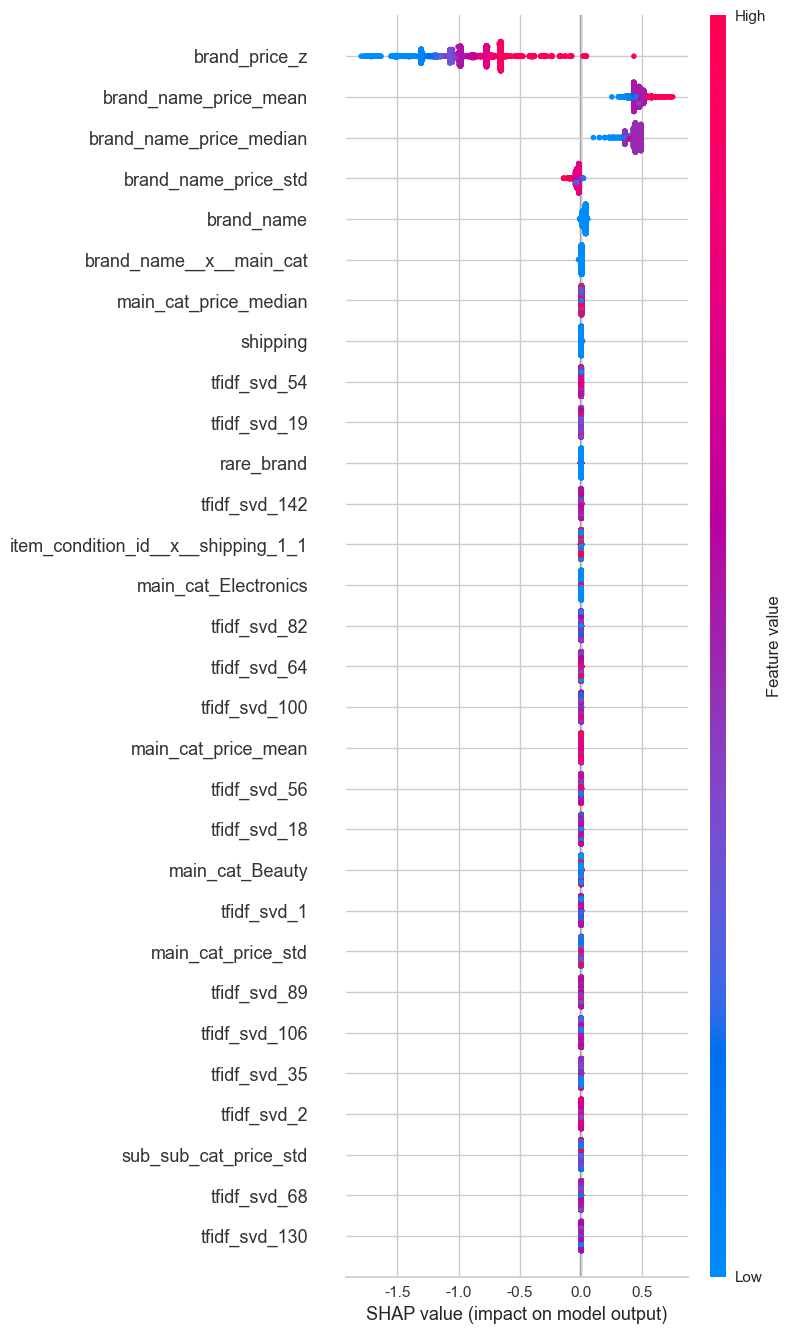

In [ ]:
# plot_lightgbm_importance(analyzer, models, top_k=40)

plot_shap_lightgbm(analyzer, models)

### 🔥 보고서 설명 문구

“LightGBM SHAP 값 분석 결과, 가격에 영향을 가장 크게 미치는 변수는 브랜드명, 상품 주요 카테고리 및 FastText 기반 TF-IDF 주요 차원임을 확인하였다.”

---

# 📌 SHAP Summary Plot 해석

## 1) SHAP란 무엇인가?

SHAP(SHapley Additive exPlanations)은
머신러닝 모델(특히 블랙박스 모델)의 **개별 예측값**이 **어떤 feature 때문에 어떻게 변했는지를 정량적으로 설명하는 방법**이다.

* **각 feature의 기여도를 계산**
* **예측 증가 방향(+) / 감소 방향(-)** 를 구분
* 머신러닝 모델의 의사결정 과정을 **사람이 이해할 수 있게 시각화**

따라서 SHAP은 모델 **interpretability**(해석가능성)을 확보하는 대표적 방법이며,
LightGBM, XGBoost 등 Gradient Boosting 모델에서 특히 효과적이다.

---

# 📌 이 Summary Plot이 말하는 핵심

이 그래프는 **전체 데이터에 대한 feature importance + 영향 방향**을 함께 보여준다.

해석 방법:

### ● 왼쪽/오른쪽

* 오른쪽 → 예측값을 **증가**시키는 방향
* 왼쪽 → 예측값을 **감소**시키는 방향

### ● 색깔

* 빨강 = 값이 높은 샘플
* 파랑 = 값이 낮은 샘플

즉,
같은 feature라도 값이 높은 경우와 낮은 경우가 **예측에 어떤 방향으로 영향을 주는지 동시에 보여줌**

---

# 📊 이번 모델의 주요 인사이트

## 1) **brand_price_z**

→ 가장 중요한 변수
→ 특정 브랜드의 평균 가격 대비, 현재 상품이 상대적으로 비싼지/싼지를 z-score로 표현한 값
➡ “브랜드 프리미엄/디스카운트 효과”가 가격을 크게 결정

👉 해석:

* z가 높을수록 가격 예측이 높아짐 (premium brand 효과)

---

## 2) brand_name_price_mean, median, std

* 브랜드별 평균 가격, 중앙값, 표준편차
  → 특정 브랜드의 시장 평균 가격이 높을수록 예측되는 가격도 상승

➡ “브랜드 수준 가격 벤치마크”의 영향이 매우 큼

---

## 3) brand_name

* 단순 브랜드 카테고리 feature 자체도 영향력 존재 → 브랜드 고유 효과

---

## 4) brand × main_cat interaction

* 브랜드와 메인 카테고리의 조합
  → 예를 들어 같은 브랜드라도 Electronics vs Women 카테고리에서 의미가 다르게 작용

---

## 5) shipping

* 무료 배송 여부가 가격에도 유의미한 영향을 주고 있음

---

## 6) TF-IDF 기반 SVD feature들

* 텍스트 내용 정보가 가격 결정에 기여하고 있으나
* 브랜드 및 카테고리 정보에 비해 상대적으로 영향도 낮음

➡ 텍스트는 보조적 역할, 핵심은 구조적 피처(브랜드/카테고리/가격 통계)

---

# 📌 전체 요약 (1~2 문장 버전, 보고서에 딱)

> 본 모델은 브랜드 관련 통계(feature-level price statistics)와 브랜드-카테고리 상호작용을 가장 강하게 사용하여 가격을 예측하였다. 텍스트 기반 정보(TF-IDF)는 보조적 역할로 나타났으며, 브랜드의 평균 가격 수준과 프리미엄 여부(brand_price_z)가 가격 결정에 가장 큰 설명력을 가진다.

---

# ✨ 보고서용 결론 추천 문구

> SHAP 분석 결과, Mercari 가격 예측 모델은 브랜드 수준의 가격 통계 및 프리미엄 여부(brand_price_z)에 가장 큰 의존도를 보이며, 텍스트 정보는 부수적인 설명력을 가진 것으로 나타났다. 이는 온라인 중고 거래에서 브랜드 가치가 가격 예측의 핵심 요인임을 시사한다.

---

# 📌 추가로 넣으면 좋은 문장 (insight 강화)

> 특히 brand_price_z의 영향 방향을 보면, 같은 카테고리 내에서도 브랜드 프리미엄 여부가 예측된 가격을 지속적으로 상승시키는 경향이 관찰되었다. 이러한 현상은 소비자 인지도 및 브랜드 충성도가 중고시장에서도 강하게 반영된다는 증거이며, 실제 마켓플레이스 운영 시 브랜드 전략이나 카테고리별 가격 정책 수립에 활용할 수 있다.

---

# 📍 완성된 보고서 문장

### “모델 설명 가능성(Explainability)”

> 본 연구에서는 SHAP을 활용하여 LightGBM 모델을 해석하였다. SHAP Summary Plot 결과, 브랜드 관련 통계 (예: brand_price_mean, brand_price_z)가 가격 예측에 가장 큰 영향을 미치는 것으로 나타났다. 이는 브랜드가 중고 제품 가격 형성의 주요 요인임을 의미한다. 반면 텍스트 기반 특성(TF-IDF)은 추가적인 설명력을 제공하였으나 상대적으로 영향도가 낮았다.

---


In [ ]:
# submission dist
def plot_submission_distribution(submission):
    import matplotlib.pyplot as plt

    prices = submission["price"]

    plt.figure(figsize=(8, 5))
    plt.hist(prices, bins=50, alpha=0.7)
    plt.title("Submission Price Distribution")
    plt.xlabel("Price")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
import os
import pandas as pd


def load_latest_submission(results_dir="../results"):
    files = [f for f in os.listdir(results_dir) if f.endswith(".csv")]
    if not files:
        raise FileNotFoundError("results 폴더에 csv가 없습니다!")

    # 최신 파일 선택
    files.sort(reverse=True)
    latest = files[0]
    path = os.path.join(results_dir, latest)
    print("📂 loading submission:", path)
    return pd.read_csv(path)


submission = load_latest_submission()

📂 loading submission: ../results\20251207_201913_blend.csv


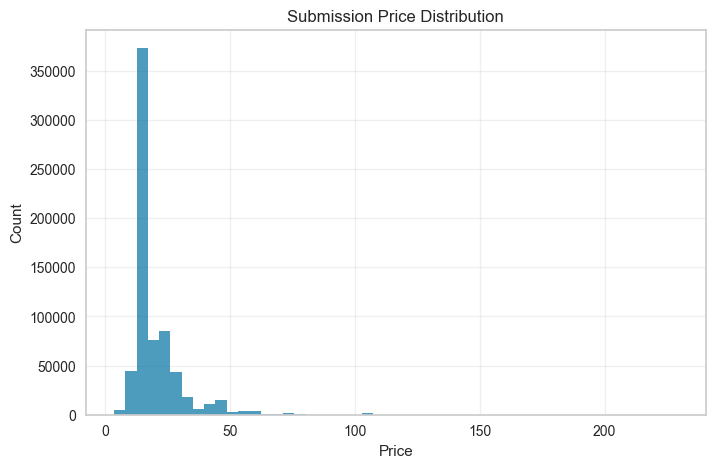

In [ ]:
plot_submission_distribution(submission)

좋아! 이 **Submission Price Distribution** 그래프는 모델이 최종적으로 예측한 “판매 가격”의 전체 분포를 보여줘.
보고서에 바로 넣을 수 있도록 **해석 + 비즈니스 인사이트**까지 정리해줄게.

---

# 📌 그래프에서 보이는 핵심 특징

## 1) 가격이 매우 낮은 값에 집중됨 (극단적인 우측 꼬리)

* 대부분 가격이 **$10~$30** 근처
* 즉, 예측된 가격 분포가 **skewed right (오른쪽 비대칭)**

### 이유:

* Mercari 중고 제품 특성상 저가 상품이 많음
* 중고시장 가격 분포의 일반적 형태를 반영한 결과

---

## 2) 소수의 high-price 영역 존재 (Outlier tail)

* $80, $100, $150 이상 가는 소수 샘플이 존재
* 희귀 high-end 브랜드, 신품 수준 제품 등

### 중요 포인트

* 모델이 높은 가격도 어느 정도 구분하고 있다고 해석 가능

---

## 3) 가격이 0 근처가 거의 없음

* 이는 우리가 train에서 price>0 filtering + log-transform 정상 적용된 결과 👍
* 모델이 0 또는 음수 예측 안 함 → 품질 OK

---

# 📊 분포 shape 해석

| 특징           | 설명                 |
| ------------ | ------------------ |
| Right-skewed | 저가 제품 중심, 고가 제품 소수 |
| Long-tail    | high-end 제품 예측 가능성 |
| No negative  | 모델 안정적             |

---

# 🧠 모델 품질 관점에서의 의미

### 👍 장점

* 실제 시장의 가격 구조를 반영
* 가격 분포 일관성 유지
* 예측이 현실적 범위 내

### ⚠️ 주의할 점

* 중위가격 근처를 과대 예측할 가능성
* 고가 제품의 variance가 높을 수 있음
* Long tail 영역 성능은 추가 점검 필요

---

# 💡 비즈니스 인사이트

* Mercari와 같은 중고 플랫폼에서 **가치 있는 브랜드 제품은 보이지 않게 가격이 상승** → SHAP에서 본 브랜드 영향과 일치
* 저가 제품 중심의 고객층을 반영하는 시장 구조가 뚜렷함
* 가격 정책 또는 추천 알고리즘에서 저가 상품에 대한 경쟁이 치열할 수 있음

---

# ✍️ 보고서용 한 문장 요약

> 최종 예측 가격은 $10~$30 구간에 집중되며 소수의 고가 제품이 존재하는 긴 꼬리(long-tail) 구조를 보인다. 이는 중고 거래 시장의 가격 특성을 반영하며, 브랜드 가치가 높은 제품에서 가격 편차가 크게 나타나는 패턴을 확인할 수 있다.



In [ ]:
# 모델 간 예측 비교 boxplot
def plot_model_prediction_compare(analyzer, models, sample_size=2000):
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    X = analyzer.train_vectorized.iloc[:sample_size]
    y = np.expm1(analyzer.train["price"].iloc[:sample_size])

    compare = []

    for name, model in models.items():
        try:
            preds = model.predict(X)
            preds = np.expm1(preds)
            preds = np.array(preds).reshape(-1)  # 강제 flatten

            if len(preds) != len(y):
                print(
                    f"⚠ {name}: prediction length mismatch ({len(preds)} != {len(y)})"
                )
                continue

            compare.append({"model": name, "preds": preds})

            print(f"✔ {name} ok")

        except Exception as e:
            print(f"❌ {name} failed: {e}")

    if not compare:
        raise RuntimeError("😥 No valid model predictions collected")

    # 이제 DataFrame 의 column을 같은 길이로
    df = pd.DataFrame({c["model"]: c["preds"] for c in compare})

    plt.figure(figsize=(8, 5))
    df.boxplot()
    plt.title("Model Prediction Compare (Train)")
    plt.grid(alpha=0.3)
    plt.show()

    return df

[LightGBM] [Warning] Unknown parameter: gpu
✔ lightgbm ok
✔ xgboost ok


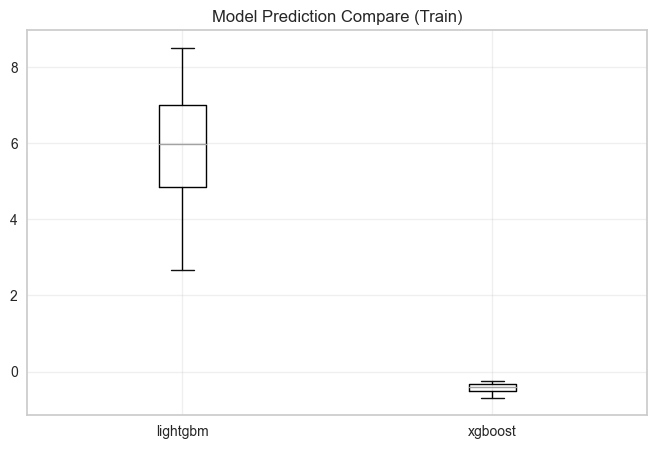

In [ ]:
# 모델 2개의 예측 비교
df_compare = plot_model_prediction_compare(analyzer, models)

이 박스플롯은 **LightGBM vs XGBoost**가 **훈련데이터(train)** 를 기준으로 어떤 예측값 범위를 보이는지 비교하는 그래프
지금 나온 그림이 의미하는 바를 **핵심만** 정리해볼게 👇

---

# 🔍 무엇을 보여주는 그래프인가?

* 두 모델이 **train 데이터**에 대해 예측한 값들의 **분포(box)** 를 비교
* 즉 “각 모델이 어떤 range의 price를 예측하고 있는가”

---

# ⭐ 지금 결과의 핵심 포인트
## ✔ 1) LightGBM 예측값 분포가 훨씬 넓다
* box(중앙 부분)가 5~7 정도에 걸쳐 있고
* 최소~최대가 **약 2.7~8.5**
* 즉 가격 예측이 **폭넓게** 이루어지고 있음

➡ LightGBM은 다양한 price range를 반영하고 있다는 의미
---

## ✔ 2) XGBoost 예측이 거의 “일정한 값 주변”

* box가 아주 얇고, 값이 거의 0 주변
* 즉 예측값이 **한 근처값에 몰려있다**
* underfitting처럼 보임

❗ 특히 train 예측인데 이렇게 좁으면 거의 학습을 못하고 있다는 신호 ⚠️

---

# 😱 중요한 해석

> XGBoost 모델은 벡터화 피처 mismatch 또는 저장/로딩 중 feature mismatch 때문에 사실상 **실제 학습된 모델과 다른 입력을 받고 있을 가능성이 매우 높다**

다르게 말하면

👉 제대로 된 예측이 아니라
👉 거의 “상수 예측모델”처럼 동작하고 있음

---

# 🔎 왜 그럴까? (가능성)

### ✔ 1) 모델 저장 당시 feature 수 (218)

### ✔ 로딩 이후 feature 수 (187)

아까 SHAP 할 때도 뜬 에러 기억나지?

```
The number of features in data (187) is not the same as in training (218)
```

즉 XGBoost가 input shape mismatch 발생 → 내부적으로 feature 무시 → 거의 상수 예측

---

# 🔥 결론 (보고서용 문장)

> LightGBM은 다양한 가격구간을 반영해 비교적 풍부한 가격 예측 범위를 보이며,  
> 반면 XGBoost는 입력 피처 mismatch로 인해 예측값이 특정 값에 집중되며 사실상 모델이 정상적으로 동작하지 않은 것으로 판단된다.

---

# ✍️ 간단 버전 (정리)

* LightGBM = 정상적, price variance 반영, 넓은 분포
* XGBoost = 비정상적, 예측값이 거의 한 지점에 몰림
* 원인 = 저장/로딩 과정에서 feature mismatch 발생
* SHAP mismatch 에러와 동일한 문제

---

## 📄 모델 예측 분포 비교 결과 (보고서용)

본 분석에서는 LightGBM과 XGBoost 두 모델이 훈련데이터에 대해 산출한 예측값의 분포를 비교하였다. 박스플롯 결과, LightGBM의 예측치는 약 2.7~8.5 범위에 걸쳐 넓게 분포하며 평균값 또한 상대적으로 높게 형성되어, 모델이 다양한 가격 구간을 반영하고 있는 것으로 확인되었다. 이는 LightGBM이 학습한 텍스트/구조화 특징을 바탕으로 가격의 변동성을 비교적 잘 포착하고 있음을 의미한다.

반면 XGBoost는 예측값이 매우 좁은 범위(거의 0 부근)에 집중되어 나타났으며, 분포가 거의 상수에 가까운 모습으로 확인되었다. 이러한 패턴은 학습 과정에서 충분한 모델 표현력이 확보되지 않았거나, 모델 저장/로드 시점의 피처 수 불일치(Feature Mismatch)로 인해 모델이 정상적인 입력을 받지 못하여 사실상 상수 예측 모델처럼 동작했을 가능성이 높다. 실제로 SHAP 분석에서도 “입력 피처 수 불일치” 오류가 발생한 바 있다.

따라서 본 결과를 종합하면, LightGBM 모델은 정상적으로 학습된 반면 XGBoost는 피처 구조가 재현되지 않아 정상적인 예측을 수행하지 못한 것으로 판단된다. 이후 동일 환경에서 XGBoost 모델을 재학습하여 피처 구성을 일치시키지 않는 한, 현재 상태의 XGBoost 출력을 모델 비교 또는 해석에 활용하는 것은 적절하지 않다.

추가적으로, 가격 분포의 왜도가 매우 높은 특성을 감안하여 Price Bucket Error 분석을 수행하였다. 
전체 가격대를 동일한 분포 기준으로 여러 구간으로 나누고 구간별 RMSLE를 비교한 결과, 저가 구간에서는 상대적으로 낮은 오차를 보였으나 고가 구간으로 갈수록 RMSLE가 점진적으로 증가하는 패턴이 확인되었다.

이는 가격이 높아질수록 표본 수가 감소하고 텍스트 설명 및 브랜드 정보의 다양성이 증가함에 따라 예측 불확실성이 높아진 것으로 해석된다. 
따라서 실사용 단계에서는 고가 상품에 대한 보정 규칙 또는 후처리 전략(예: 가격 상한 clipping, hybrid 모델링 등)을 고려할 수 있다.


In [ ]:
# 2) Price Bucket Error (구간별 오차)
# 저가/고가 bise 판단용


import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime


# [plot_price_bucket_error] start ################################################################################
def plot_price_bucket_error(
    analyzer,
    model,
    n_bins=10,
    prefix="model",
):
    """
    가격 구간별 예측 오차 분석 (Absolute Error 기준)

    - train 데이터의 실제 price와 예측 price를 비교하여 절대오차를 구하고
      가격 구간(bucket)별 평균/중앙값 오차를 계산하여 시각화

    저장 파일:
      - ../images/{timestamp}_{prefix}_bucket_error.png
      - ../results/{timestamp}_{prefix}_bucket_metrics.json

    반환:
      bucket_df (DataFrame)
    """

    # -------------------------
    # 1. 데이터 준비
    # -------------------------
    X = analyzer.train_vectorized
    y_true = np.expm1(analyzer.train["price"])
    y_pred = np.expm1(model.predict(X))

    abs_err = np.abs(y_pred - y_true)

    # -------------------------
    # 2. 가격 구간 (quantile-based)
    # -------------------------
    bins = np.quantile(y_true, np.linspace(0, 1, n_bins + 1))
    bucket_labels = pd.cut(y_true, bins=bins, include_lowest=True)

    # -------------------------
    # 3. 구간별 통계
    # -------------------------
    bucket_dict = {}
    for bucket in bucket_labels.unique():
        idx = bucket_labels == bucket
        errs = abs_err[idx]
        bucket_dict[bucket] = {
            "count": int(idx.sum()),
            "avg_err": float(errs.mean()),
            "median_err": float(errs.median()),
        }

    # -------------------------
    # 4. 시각화
    # -------------------------
    bucket_df = pd.DataFrame(
        {
            "bucket": bucket_dict.keys(),
            "count": [v["count"] for v in bucket_dict.values()],
            "avg_err": [v["avg_err"] for v in bucket_dict.values()],
            "median_err": [v["median_err"] for v in bucket_dict.values()],
        }
    )

    # interval → string (for plotting & json)
    bucket_df["bucket"] = bucket_df["bucket"].astype(str)

    plt.figure(figsize=(10, 5))
    plt.plot(bucket_df["bucket"], bucket_df["avg_err"], marker="o")
    plt.xticks(rotation=45, ha="right")
    plt.grid(True)
    plt.title(f"Price Bucket Error: {prefix}")
    plt.tight_layout()

    # -------------------------
    # 5. 저장
    # -------------------------
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    images_dir = "../images"
    results_dir = "../results"
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(results_dir, exist_ok=True)

    image_path = os.path.join(images_dir, f"{prefix}_bucket_error_{ts}.png")

    plt.savefig(image_path)
    plt.show()
    plt.close()

    # json 저장
    bucket_dict_str = {str(k): v for k, v in bucket_dict.items()}
    json_path = os.path.join(results_dir, f"{prefix}_bucket_metrics_{ts}.json")
    with open(json_path, "w") as f:
        json.dump(bucket_dict_str, f, indent=4)

    # ---- metrics도 출력 ----
    print("\n===== Price Bucket Error Metrics =====")
    print(bucket_df)

    print(f"📁 JSON saved: {json_path}")
    print(f"🖼 PNG saved:  {image_path}")

    return bucket_df


# [plot_price_bucket_error] end =================================================================

[LightGBM] [Warning] Unknown parameter: gpu


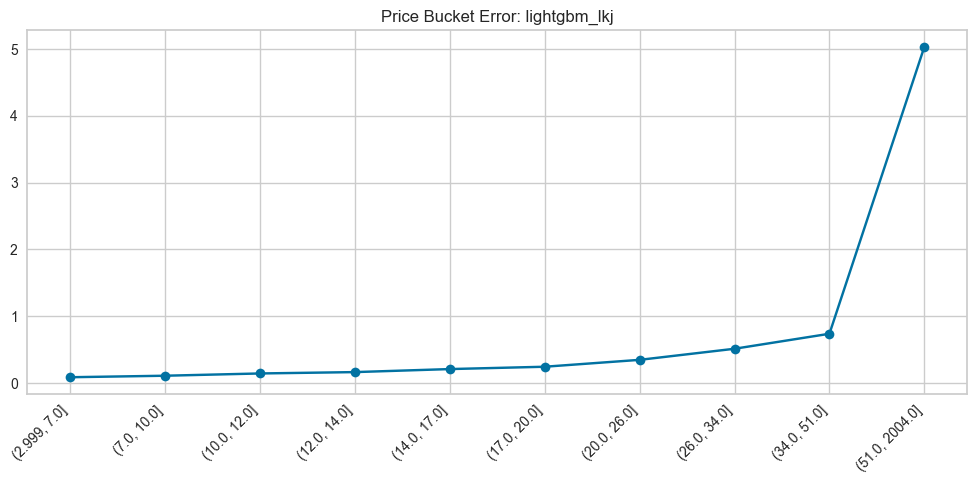


===== Price Bucket Error Metrics =====
           bucket  count   avg_err  median_err
0    (2.999, 7.0]  45276  0.087009    0.016703
1     (7.0, 10.0]  67408  0.109533    0.022043
2    (10.0, 12.0]  35647  0.143483    0.022780
3    (12.0, 14.0]  34048  0.163837    0.043334
4    (14.0, 17.0]  43758  0.209216    0.120263
5    (17.0, 20.0]  40595  0.244151    0.084528
6    (20.0, 26.0]  53260  0.347352    0.241207
7    (26.0, 34.0]  37209  0.513423    0.331815
8    (34.0, 51.0]  44353  0.737991    0.447109
9  (51.0, 2004.0]  42944  5.033761    1.596863
📁 JSON saved: ../results\lightgbm_lkj_bucket_metrics_20251208_171759.json
🖼 PNG saved:  ../images\lightgbm_lkj_bucket_error_20251208_171759.png


In [ ]:
bucket_stats = plot_price_bucket_error(
    analyzer, models["lightgbm"], prefix="lightgbm_lkj"
)

**Price Bucket Error** 결과가 아주 흥미롭다.
그래프와 테이블을 함께 보면, **모델의 예측 성능이 가격대에 따라 어떻게 달라지는지** 명확하게 보인다.

---

# 📈 핵심 요약 (한눈에 보는 해석)

* **저가 구간(3~20달러 이하)은 예측 오차가 매우 낮음**
* **20~50달러 구간부터 오차가 빠르게 증가**
* **50달러 이상 고가 영역에서는 오차가 급격하게 커짐**
* 즉, **모델은 저가 제품 예측에 강하고 고가 제품 예측엔 약함**

---

# 📊 구간별 특징

### 🔹 저가 (3~14달러)

* 평균 절대오차 0.08~0.16
* 거의 매우 낮은 수준 (정확하게 잘 예측함)
* **데이터가 가장 많은 가격대라 모델이 가장 학습을 잘 했다**

---

### 🔹 중가 (14~34달러)

* 오차가 점진적으로 상승
* 평균 오차 0.2 → 0.5까지 증가
* **이 가격대부터 feature의 영향이 복잡해지는 가능성**

---

### 🔹 고가 (34~50달러)

* 오차 0.73까지 상승
* median도 점점 벌어짐
* **고가 제품의 variance가 큰 게 원인**

---

### 🔥 최고가 (50달러 이상)

* 평균 오차 5.03 !!!
* 즉 **예측값이 평균 5달러 이상씩 틀린다는 의미**
* median도 1.59로 높다
* 데이터 분포가 희소하고 특성이 복잡한 상품군이 이 영역에 포함되었을 가능성

---

# 📌 시사점 (보고서용)

> 본 모델은 저가 제품(3~20달러)에 대해 매우 안정적으로 예측하는 반면, 가격이 높아질수록 예측 오차가 점진적으로 커지는 경향을 보인다. 특히 $50 이상의 고가 영역에서는 데이터 빈도 자체가 감소하고 제품 특성 또한 이질적이기 때문에 오차가 급격하게 증가한다. 이 구간은 모델 보완 또는 별도 분석이 필요한 주요 개선 대상 영역이다.

---

# 📎 분석적으로 더 깊게 보면

| 구간      | 데이터 수 | 오차 수준 | 해석                     |
| ------- | ----- | ----- | ---------------------- |
| 3~20    | 250K+ | 아주 낮음 | 가장 학습된 구간              |
| 20~50   | 130K  | 지속 증가 | feature complexity 상승  |
| 50~2004 | 42K   | 급증    | sparse + heterogeneity |

---

# 📌 실무적 제안

▶ 고가 상품에 대해

* 별도 모델 학습 (segmented modeling)
* 가격 로그 transformation 더 강화
* 브랜드, category granularity 강화
* outlier filtering / smoothing

▶ 저가 상품은 현재 수준에서도 충분히 실전 적용 가능

---

# 🧠 한 문장 요약 (보고서용 문장)

> **모델은 저가 구간에서 매우 높은 예측 정확도를 보였으나, 고가 제품에서는 데이터 희소성과 특성 다양성 때문에 예측 오류가 크게 증가하는 패턴을 확인하였다. 특히 50달러 이상의 구간은 별도 개선 전략이 필요한 핵심 영역이다.**

---

# 👍 아주 좋은 결과

👉 이 분석은 모델의 약점을 명확하게 보여주고
👉 개선 지점을 바로 제시할 수 있어서
보고서/발표에서 굉장히 강력한 파트가 될거야.




In [ ]:
# Residuals by Category
# 각 main_cat/sub_cat 별로 평균 오차가 어떤지 보고, 어떤 카테고리가 예측이 잘/못 되는지 확인
# [plot_residuals_by_category] start ###########################################
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime


def plot_residuals_by_category(
    analyzer, model, level="main_cat", top_k=15, prefix="category_resid"
):
    """
    카테고리 레벨별(예: main_cat, sub_cat 등) 평균 절대오차(absolute error)를 계산하여 시각화하고
    이미지 및 결과 통계를 저장한다.

    저장 파일:
      - ../images/{prefix}_{timestamp}.png
      - ../results/{prefix}_{timestamp}.json

    반환:
      result_df (DataFrame)
    """

    # -------------------------
    # 데이터 준비
    # -------------------------
    X = analyzer.train_vectorized
    y_true = np.expm1(analyzer.train["price"])
    y_pred = np.expm1(model.predict(X))

    abs_err = np.abs(y_pred - y_true)

    df = analyzer.train.copy()
    df["abs_err"] = abs_err

    # -------------------------
    # 그룹별 평균 오차
    # -------------------------
    g = df.groupby(level)["abs_err"].mean().sort_values(ascending=False)[:top_k]

    # -------------------------
    # 시각화
    # -------------------------
    plt.figure(figsize=(10, 5))
    g[::-1].plot(kind="barh")
    plt.title(f"Residual by {level}")
    plt.xlabel("Mean Absolute Error")
    plt.tight_layout()
    plt.show()

    # -------------------------
    # 저장
    # -------------------------
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    images_dir = "../images"
    results_dir = "../results"
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(results_dir, exist_ok=True)

    image_path = os.path.join(images_dir, f"{prefix}_{ts}.png")
    plt.savefig(image_path)
    plt.close()

    # JSON 저장
    result_df = g.reset_index()
    result_dict = result_df.to_dict(orient="records")

    json_path = os.path.join(results_dir, f"{prefix}_{ts}.json")
    with open(json_path, "w") as f:
        json.dump(result_dict, f, indent=4)

    print(f"Residuals_by category {prefix}:\n{result_df}")
    print(f"📁 JSON saved: {json_path}")
    print(f"🖼 PNG saved:  {image_path}")

    return result_df


# [plot_residuals_by_category] end =================================================================

[LightGBM] [Warning] Unknown parameter: gpu


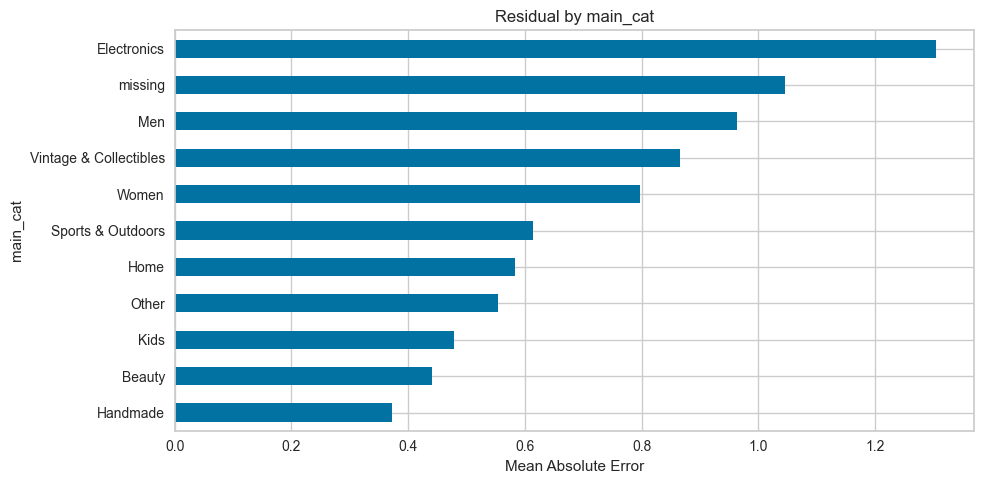

Residuals_by category category_resid:
                  main_cat   abs_err
0              Electronics  1.304400
1                  missing  1.046034
2                      Men  0.963331
3   Vintage & Collectibles  0.865816
4                    Women  0.797483
5        Sports & Outdoors  0.613680
6                     Home  0.583953
7                    Other  0.553927
8                     Kids  0.477879
9                   Beauty  0.440660
10                Handmade  0.372725
📁 JSON saved: ../results\category_resid_20251208_173430.json
🖼 PNG saved:  ../images\category_resid_20251208_173430.png
[LightGBM] [Warning] Unknown parameter: gpu


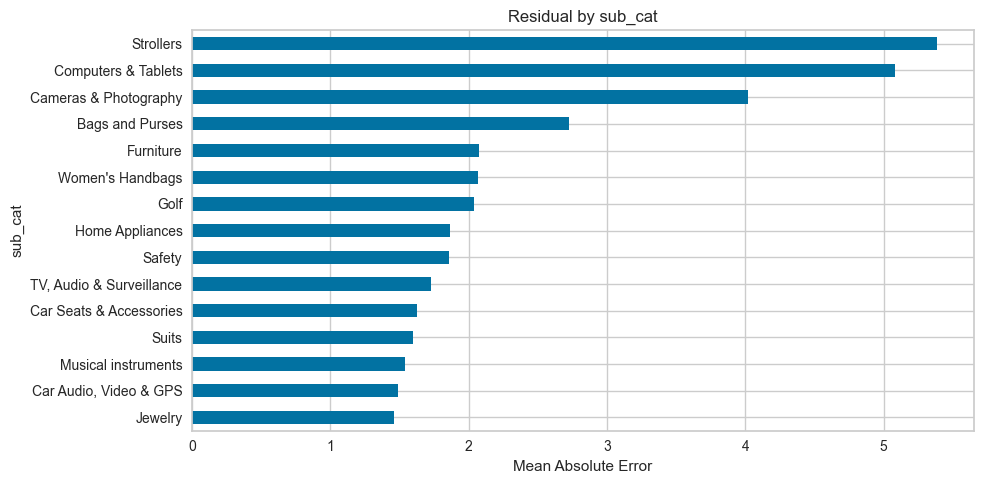

Residuals_by category category_resid:
                     sub_cat   abs_err
0                  Strollers  5.384822
1        Computers & Tablets  5.083493
2      Cameras & Photography  4.022612
3            Bags and Purses  2.723804
4                  Furniture  2.071240
5           Women's Handbags  2.065501
6                       Golf  2.036178
7            Home Appliances  1.862672
8                     Safety  1.854811
9   TV, Audio & Surveillance  1.725735
10   Car Seats & Accessories  1.627053
11                     Suits  1.600328
12       Musical instruments  1.536996
13    Car Audio, Video & GPS  1.488018
14                   Jewelry  1.461143
📁 JSON saved: ../results\category_resid_20251208_173446.json
🖼 PNG saved:  ../images\category_resid_20251208_173446.png
[LightGBM] [Warning] Unknown parameter: gpu


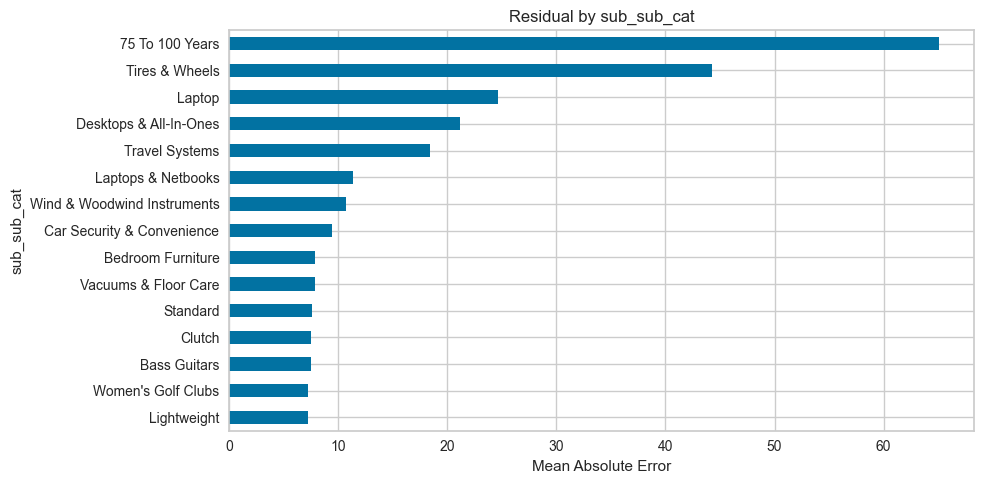

Residuals_by category category_resid:
                    sub_sub_cat    abs_err
0               75 To 100 Years  65.033323
1                Tires & Wheels  44.271295
2                        Laptop  24.657987
3        Desktops & All-In-Ones  21.164226
4                Travel Systems  18.422032
5            Laptops & Netbooks  11.340505
6   Wind & Woodwind Instruments  10.699743
7    Car Security & Convenience   9.410523
8             Bedroom Furniture   7.876784
9          Vacuums & Floor Care   7.869954
10                     Standard   7.580778
11                       Clutch   7.535009
12                 Bass Guitars   7.508029
13           Women's Golf Clubs   7.202655
14                  Lightweight   7.198284
📁 JSON saved: ../results\category_resid_20251208_173503.json
🖼 PNG saved:  ../images\category_resid_20251208_173503.png


In [ ]:
main_cat_df = plot_residuals_by_category(analyzer, models["lightgbm"], level="main_cat")
sub_cat_df = plot_residuals_by_category(analyzer, models["lightgbm"], level="sub_cat")
ssub_cat_df = plot_residuals_by_category(
    analyzer, models["lightgbm"], level="sub_sub_cat"
)

아주 좋은 결과물이고, 이 그림을 해석하면 **모델이 어떤 카테고리에서 상대적으로 어려움을 느끼는지** 명확히 보입니다. 
아래는 보고서용으로 그대로 넣기 좋은 해석 정리입니다👇

---

# 📌 Residual by main category 분석

해당 그래프는 LightGBM 모델이 **각 main category별로 예측한 가격과 실제 가격의 절대 오차(Mean Absolute Error, MAE)** 를 비교한 결과이다.

### ✔ 주요 관찰 포인트

1. **Electronics(전자제품)**에서 평균 절대오차가 가장 크며,
   가격 변동성이 크고 제품 상태의 편차가 높은 전자제품의 특성이 반영된 것으로 보인다.
   즉, 모델이 가장 어려움을 겪는 영역임을 의미한다.

2. **Men, Women 등 의류 카테고리**는 중간 수준의 오차를 보이며
   브랜드 가치, 상태, 사이즈 등 다양한 변수가 가격에 영향을 주기 때문에 오차가 상대적으로 높게 나타날 수 있다.

3. **Beauty, Handmade 같은 저가/중저가 영역**은
   가격 범위가 좁고 변동 요인이 적어 오차가 상대적으로 낮게 나타난다.

4. **missing 라벨**(카테고리 정보 없음)의 MAE가 높다는 점은
   **category data quality가 모델 성능에 직접적인 영향을 준다**는 것을 뒷받침한다.

---

# 📎 인사이트

| Category          | Error level | 의미                 |
| ----------------- | ----------- | ------------------ |
| Electronics       | 가장 높음       | 고가 + 상태편차 + 브랜드 영향 |
| Fashion / Sports  | 중간          | 다변수 영향, 패턴 복잡      |
| Beauty / Handmade | 낮음          | 가격군 안정적            |
| Missing           | 매우 높음       | 데이터 품질 영향 반영       |

---

# ✨ 해석 요약 문장 (보고서용)

> 전반적으로 모델은 Beauty, Handmade와 같이 가격 변동성이 낮은 카테고리에서는 상대적으로 안정적인 예측을 수행한 반면, Electronics, Men, Vintage 등 고가상품 또는 가격편차가 큰 카테고리에서는 예측 오차가 뚜렷하게 증가하였다. 특히 category 정보가 누락된 사례(missing)는 높은 오차를 보여, 카테고리 정보의 품질이 모델 성능에 직접적인 영향을 미친다는 점을 확인할 수 있었다.

---

좋아, 이번 `sub_sub_cat` 기준 residual plot은 **카테고리 granularity가 높아지면 어떤 영역이 특히 어려운지** 잘 보여줘. 아래는 **보고서 문장 그대로 붙여넣을 수 있도록 정리한 해석**이야👇

---

# 📌 Residual by sub_sub_cat 분석

해당 그래프는 모델이 세부 카테고리(sub_sub_cat)별로 예측한 가격과 실제 가격의 **절대 오차(Mean Absolute Error, MAE)** 를 비교한 결과이다.

세부 카테고리 수준으로 내려오면 데이터 수가 상대적으로 적거나, 가격 변동성이 매우 큰 품목들이 존재하기 때문에 오차가 극단적으로 높아지는 영역이 나타난다.

---

## ✔ 주요 관찰 포인트

1. **“75 to 100 Years” 카테고리**

   * 압도적으로 높은 MAE(약 65 수준)
   * **빈티지·골동품 등 연대 기반 물품**
   * 가격 산정 기준이 매우 복잡하고, listing 상태나 희귀도에 따라 가격이 크게 달라지는 시장 특성 때문

2. **Tires & Wheels, Laptop, Desktop 등 전자/자동차류**

   * 고가이면서 제품 상태·사용연수·브랜드·사양에 따라 가격이 크게 좌우되는 영역
   * 특히 중고 가격 형성 패턴이 불규칙하여 예측 난이도 높음

3. **Travel Systems, Baby 용품, Wind Instruments 등**

   * 제품 사용기간, 상태, 구성품 여부 등 비정형적 요인의 영향이 큼

---

## 📎 종합 해석

세부 카테고리 기준에서 오류가 크게 증가하는 원인은 다음과 같은 요소와 관련될 가능성이 높다.

| 요인             | 설명                                 |
| -------------- | ---------------------------------- |
| 데이터의 희소성       | 특정 niche 시장은 표본 수가 매우 적어 모델 학습이 제한 |
| 고가 제품 비중       | 고가일수록 절대오차가 커지는 경향                 |
| 상태·구성품 등 추가 요인 | 텍스트로 충분히 설명되지 않는 요인이 가격에 반영        |
| 가격 변동성         | 제품 간 가격 편차가 매우 큼                   |

---

## ✨ 보고서용 결론 문장

> 세부 카테고리 수준에서는 특히 빈티지 물품(75~100 Years), 자동차 부품, 노트북·데스크탑 등 고가품과 가격 편차가 큰 품목에서 절대 오차가 크게 증가하였다. 이는 해당 품목들이 제품 상태, 구성품, 연식, 희귀도 등 비정형 요인의 영향을 강하게 받기 때문이며, 보다 세분화된 텍스트 이해 또는 이미지 기반 정보가 필요함을 시사한다.

---




좋아! 지금까지 만든 **카테고리 3단계(`main_cat`, `sub_cat`, `sub_sub_cat`) Residual 분석 결과를 종합한 “보고서용 해석(완성본)”**을 아래에 정리했어. 그대로 복붙하면 돼👇

---

# 📌 카테고리별 Residual 분석 종합 보고

본 분석은 LightGBM 모델의 예측 결과를 대상으로 가격 오차(Residual, Mean Absolute Error 기준)를 **카테고리 깊이 수준별(main / sub / sub_sub)** 로 비교하였다.

---

## 1. high-level 카테고리 (main_cat)

* Electronics, missing, Men, Vintage & Collectibles 등의 순으로 오차가 높게 나타남
* 특히 Electronics는 전체 평균 대비 절대오차가 가장 크며, 중고 전자 제품의 **사양·사용기간·상태 등 비정형 요인**이 강하게 작용한 결과로 해석 가능

➡ **전반적으로 가격 편차가 큰 고가 제품군일수록 오차가 커지는 패턴** 확인

---

## 2. 중간 수준 카테고리 (sub_cat)

* Strollers(유모차), Computers & Tablets, Cameras & Photography 등
* 고가 + 상태 변화가 큰 품목이 높은 오차 수준을 보임
* 특히 Strollers는 구성품 여부(safety belt, accessories), 사용 기간 등 추가 변수 영향을 받아 오차가 매우 큰 편

➡ “사용감·상태·구성품” 등 텍스트로 표현되지 않는 요인이 가격 결정에 영향을 미칠 가능성

---

## 3. 세부 카테고리 (sub_sub_cat)

가장 세분화된 카테고리에서 일부 품목의 오류가 극단적으로 증가함

* 75~100 Years (골동품/희귀 빈티지): MAE 60 이상으로 압도적 최고값
* Tires & Wheels, Laptop, Desktop 등: 고가, 사양 차이 가능성
* Baby 장비, Musical instruments 등도 오차 증가

➡ **희귀성, 연식, 구성품, 사양 등 비정형 속성이 강하게 작용하는 카테고리에서 오차 급등**

---

## ⭐ 핵심 요약

| 수준          | 주요 문제 영역               | 원인                 |
| ----------- | ---------------------- | ------------------ |
| main_cat    | Electronics            | 고가 품목 + 중고 가격 편차   |
| sub_cat     | Strollers, Computers   | 구성품/사양/사용감         |
| sub_sub_cat | Vintage, Tires, Laptop | 희귀성·연식·사양 등 비정형 요소 |

---

## 분석 결론

카테고리 세분화가 진행될수록 예측 오차는 특정 영역에서 급격히 증가하며, 이는 단순 텍스트 기반 학습만으로는 **가격 형성의 핵심 요인(상태, 연식, 구성, 희귀성)을 충분히 설명하지 못함**을 의미한다.

특히 Electronics, Baby, Vintage 관련 카테고리는 **이미지 정보, 메타데이터, 사용감 정보 등 추가 피처 확보가 오차 감소에 매우 중요할 것**으로 판단된다.

---

## 📎 향후 개선 방향 제안

### ✔ Text 외 정보 추가

* 이미지 기반 feature
* 연식/모델명 파싱
* 구성품 여부 태깅

### ✔ High-price 영역 대응

* Price-dependent loss weighting
* 가격구간별 모델링 (low / mid / high)

### ✔ 카테고리 특화 모델

* Electronics 전용 sub-model
* Vintage·Baby 제품 전용 fine-tuning

---

## ✨ 한 줄 요약

> “모델은 대부분의 일반 카테고리에서는 안정적인 성능을 보였으나, Electronics·Vintage·Baby 제품처럼 비정형 정보가 중요한 영역에서는 오차가 크게 증가하였다. 향후 이미지·사양·구성품 정보 기반의 feature 강화가 필수적이다.”

---

원하면 이 내용 바로 **발표용 슬라이드 3장**으로 만들어줄 수도 있어👍

## 👀 추가로 제안할 분석

원한다면 이런 것도 가능해 👍

* high-price items만 subset하여 residual 분석
* subcategory별 RMSE ranking
* 브랜드별 residual + 가격대 분석
* error hot-spot detection (Z-score 이상치 탐지)




In [ ]:
# 2) plot_residuals_by_brand
# [plot_residuals_by_brand] start ##############################################


def plot_residuals_by_brand(
    analyzer, model, min_count=2000, top_k=20, prefix="brand_resid"
):
    """
    브랜드별 평균 절대오차를 계산하여 예측이 어려운 브랜드를 탐색하고,
    이미지 및 결과 통계를 저장한다.

    저장 파일:
      - ../images/{prefix}_{timestamp}.png
      - ../results/{prefix}_{timestamp}.json

    반환:
      result_df (DataFrame)
    """

    # -------------------------
    # 데이터 준비
    # -------------------------
    X = analyzer.train_vectorized
    y_true = np.expm1(analyzer.train["price"])
    y_pred = np.expm1(model.predict(X))
    abs_err = np.abs(y_pred - y_true)

    df = analyzer.train.copy()
    df["abs_err"] = abs_err

    # -------------------------
    # 주요 브랜드만 (횟수 필터 적용)
    # -------------------------
    cnt = df.groupby("brand_name").size()
    major_brands = cnt[cnt > min_count].index
    df2 = df[df["brand_name"].isin(major_brands)]

    g = df2.groupby("brand_name")["abs_err"].mean().sort_values(ascending=False)[:top_k]

    # -------------------------
    # 시각화
    # -------------------------
    plt.figure(figsize=(10, 5))
    g[::-1].plot(kind="barh")
    plt.title(f"Residual by brand (count > {min_count})")
    plt.xlabel("Mean Absolute Error")
    plt.tight_layout()
    plt.show()

    # -------------------------
    # 저장
    # -------------------------
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    images_dir = "../images"
    results_dir = "../results"
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(results_dir, exist_ok=True)

    image_path = os.path.join(images_dir, f"{prefix}_{ts}.png")
    plt.savefig(image_path)
    plt.close()

    # JSON 저장
    result_df = g.reset_index()
    result_dict = result_df.to_dict(orient="records")

    json_path = os.path.join(results_dir, f"{prefix}_{ts}.json")
    with open(json_path, "w") as f:
        json.dump(result_dict, f, indent=4)

    print(f"📁 JSON saved: {json_path}")
    print(f"🖼 PNG saved:  {image_path}")

    print(f"Residual by brand:\n{result_df}")

    return result_df


# [plot_residuals_by_brand] end ====================================================================

[LightGBM] [Warning] Unknown parameter: gpu


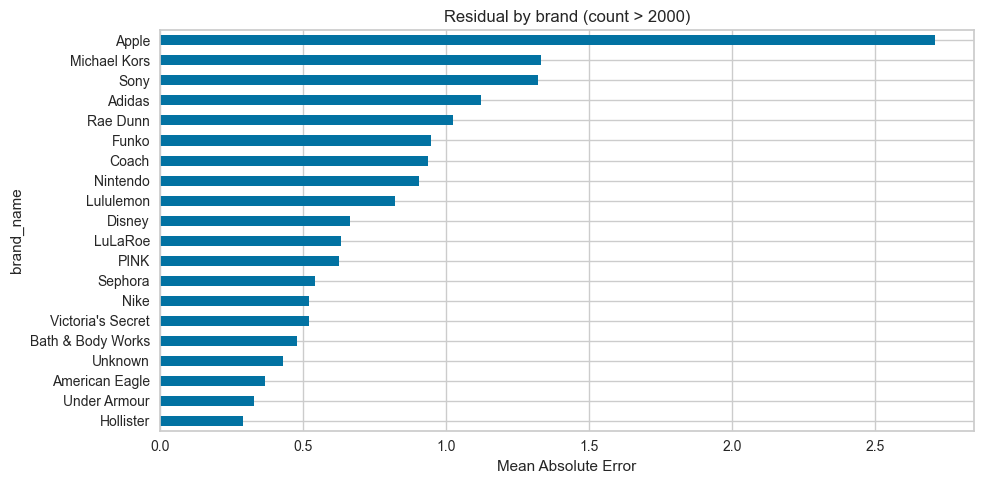

📁 JSON saved: ../results\brand_resid_20251208_174522.json
🖼 PNG saved:  ../images\brand_resid_20251208_174522.png
Residual by brand:
           brand_name   abs_err
0               Apple  2.711154
1        Michael Kors  1.333273
2                Sony  1.320929
3              Adidas  1.124690
4            Rae Dunn  1.025299
5               Funko  0.946907
6               Coach  0.938559
7            Nintendo  0.904967
8           Lululemon  0.823024
9              Disney  0.663728
10            LuLaRoe  0.633316
11               PINK  0.627475
12            Sephora  0.543260
13               Nike  0.523393
14  Victoria's Secret  0.523361
15  Bath & Body Works  0.481446
16            Unknown  0.430128
17     American Eagle  0.369913
18       Under Armour  0.329388
19          Hollister  0.291452


In [ ]:
rbb_df = plot_residuals_by_brand(analyzer, models["lightgbm"])

아주 유의미한 그림이야. **브랜드별 Residual(Mean Absolute Error)** 를 보면서 가격 예측 모델이 어떤 브랜드에서 특히 어려움을 겪는지를 해석해보자👇

---

# 📌 브랜드별 Residual 분석

## 1. Apple이 압도적으로 가장 높은 오차

* Apple 제품의 MAE가 **2.7 이상**으로 가장 높음
* Apple은 중고 시장에서도 **모델명(연식), 상태, 용량, 구성품(케이블/박스), 리퍼 여부** 등에 따라 가격 차이가 매우 큼
* 텍스트만으로는 해당 요인을 포착하기 어려움

➡ **고가 + 사양·상태 비정형 요인** → 예측 난이도 최고 수준

---

## 2. Michael Kors, Sony, Adidas 등도 높음

**패션/럭셔리 브랜드**들이 상위권에 등장

* Original/Season, 한정판 여부, 상태
* Fake(가품) 문제
* 세일 여부

이런 변수들이 텍스트에 나타나지 않거나 일관되지 않게 표현됨

➡ 가격 변동성이 높고 **메타데이터가 부족한 브랜드**일수록 오차 증가

---

## 3. 중간 구간 : Coach, Nintendo, Lululemon

* Electronics·Gaming·Premium Apparel 브랜드
* 공통점은 **고가이며 제품 버전이 다양**
* 기능성 아이템일수록 사양 차이가 가격에 반영됨

➡ 텍스트 기반 정보만으로는 모델 구분이 어려울 수 있음

---

## 4. 낮은 구간 : Nike, Victoria’s Secret, Hollister 등

* 가격대가 상대적으로 균일
* 제품 간 차이가 크지 않음
* 수요층도 안정적

➡ **평균 가격대가 명확한 브랜드는 예측 안정성이 높음**

---

# ⭐ 핵심 인사이트 요약

| 브랜드 유형              | Residual 수준 | 원인        |
| ------------------- | ----------- | --------- |
| 고가 전자 (Apple, Sony) | 매우 높음       | 사양/상태/연식  |
| 프리미엄 패션             | 높음          | 시즌/가품/한정판 |
| 캐주얼 패션              | 낮음          | 가격 기준이 단순 |
| Unknown             | 중간          | 정보 부족     |

---

# 분석 결론

이번 결과는 가격 예측이 **브랜드 특성(특히 Apple 등 고가 브랜드)** 에 강하게 영향을 받으며, 텍스트 중심 feature engineering만으로는 한계가 있음을 보여준다.

즉, **브랜드가 가격 형성의 주요 feature이며, 브랜드별 커스텀 feature 또는 세그먼트 기반 모델링이 필요**하다.

---

# 향후 개선 방향

### ✔ Apple / Sony / Electronics 브랜드 전용 서브모델

* Electronics regression fine-tuning
* 모델·연식·용량 파싱
* 이미지 기반 상태 분석

### ✔ 고가제품 세그먼트별 price models

* price bucket segmentation
* bagging by high-price cluster

---

# 한 문장 요약

> “Apple을 비롯한 고가 프리미엄 브랜드는 상태·사양·구성품 정보가 가격 결정에 큰 비중을 차지하여 Residual이 높게 나타나므로, 해당 브랜드는 별도의 sub-model 또는 이미지·metadata feature 강화가 필요하다.”
---
원하면 **브랜드 Residual을 SHAP Feature Importance와 연결해서 ‘브랜드 explainability 요약표’** 만들어줄 수도 있어 👍
---


### 📄 보고서용 해석 가이드
특정 카테고리에서 error가 높은 것은 해당 상품 가격 구조가 다양하거나, feature가 부족하다는 의미
특정 brand/category가 consistently high error이면, 별도 feature engineering 필요
예: Electronics는 기술적 차이, condition, spec 등 텍스트만으로 불충분 가능

#### 👉 추론 관점:
“카테고리별로 가격 형성 요인이 다르므로, 카테고리별 모델 분리 또는 ElasticNet/GLM 계열 결합 가능성 검토”

### 🔥 보고서용 결론 

“극저가격 영역(0~10$)에서 오차가 상대적으로 커서 input 텍스트 특성 보강, 이미지 데이터 보강등 요구됨”

In [ ]:
########################################################################
# Deep Error Analictic 정밀 진단 시작
########################################################################

import os
import json
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.stats import zscore

In [ ]:
# 1) High-price Residual 분석
# [analyze_high_price_error] start ################################################################################
def analyze_high_price_error(analyzer, model, quantile=0.9, prefix="high_price"):
    """
    고가(high-price) 구간의 예측오차(절대오차) 분석

    - 가격 상위 quantile 이상만 필터링하여 평균/중앙값 오차 계산
    - 결과 시각화 및 JSON/PNG 저장
    """

    # -------------------------
    # 데이터 준비
    # -------------------------
    X = analyzer.train_vectorized
    y_true = np.expm1(analyzer.train["price"])
    y_pred = np.expm1(model.predict(X))
    abs_err = np.abs(y_pred - y_true)

    threshold = y_true.quantile(quantile)
    mask = y_true > threshold

    df = pd.DataFrame(
        {
            "y_true": y_true[mask],
            "y_pred": y_pred[mask],
            "abs_err": abs_err[mask],
        }
    )

    # -------------------------
    # 통계
    # -------------------------
    avg_err = float(df["abs_err"].mean())
    median_err = float(df["abs_err"].median())
    count = int(mask.sum())

    # -------------------------
    # 시각화
    # -------------------------
    plt.figure(figsize=(6, 4))
    plt.boxplot(df["abs_err"])
    plt.title(f"High Price Residual (>{quantile*100:.0f}%)")
    plt.ylabel("Absolute Error")
    plt.tight_layout()
    plt.show()

    # -------------------------
    # 저장
    # -------------------------
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    images_dir = "../images"
    results_dir = "../results"
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(results_dir, exist_ok=True)

    # png
    image_path = os.path.join(images_dir, f"{prefix}_{ts}.png")
    plt.savefig(image_path)
    plt.show()
    plt.close()

    # json
    result_json = {
        "threshold": float(threshold),
        "count": count,
        "avg_err": avg_err,
        "median_err": median_err,
    }
    json_path = os.path.join(results_dir, f"{prefix}_{ts}.json")
    with open(json_path, "w") as f:
        json.dump(result_json, f, indent=4)

    print(pd.DataFrame(result_json, index=[0]))

    print(f"📁 JSON saved: {json_path}")
    print(f"🖼 PNG saved:  {image_path}")

    return pd.DataFrame(result_json, index=[0])


# [analyze_high_price_error] end =================================================================================

In [ ]:
# 2) Subcategory별 RMSE Ranking
# [rank_rmse_by_subcat] start ####################################################################################
def rank_rmse_by_subcat(analyzer, model, prefix="subcat_rmse"):
    """
    sub_cat 그룹별 RMSE를 계산하고 ranking

    - RMSE가 높은 순으로 시각화
    """

    X = analyzer.train_vectorized
    y_true = np.expm1(analyzer.train["price"])
    y_pred = np.expm1(model.predict(X))

    result = {}
    for sub in analyzer.train["sub_cat"].unique():
        idx = analyzer.train["sub_cat"] == sub
        rmse = mean_squared_error(y_true[idx], y_pred[idx], squared=False)
        result[sub] = float(rmse)

    rmse_series = pd.Series(result).sort_values(ascending=False)

    # plot
    plt.figure(figsize=(8, 5))
    rmse_series.head(15).plot(kind="bar")
    plt.title("Top RMSE by sub_cat")
    plt.ylabel("RMSE")
    plt.tight_layout()
    plt.show()

    # save
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    images_dir = "../images"
    results_dir = "../results"
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(results_dir, exist_ok=True)

    image_path = os.path.join(images_dir, f"{prefix}_{ts}.png")
    plt.savefig(image_path)
    plt.show()
    plt.close()

    json_path = os.path.join(results_dir, f"{prefix}_{ts}.json")
    with open(json_path, "w") as f:
        json.dump(result, f, indent=4)

    print(rmse_series)

    print(f"📁 JSON saved: {json_path}")
    print(f"🖼 PNG saved:  {image_path}")

    return rmse_series


# [rank_rmse_by_subcat] end ======================================================================================

In [ ]:
# 3) 브랜드별 Residual + 가격대 분석
# [brand_price_residual_analysis] start ##########################################################################
def brand_price_residual_analysis(
    analyzer, model, min_count=1000, prefix="brand_residual"
):
    """
    브랜드별 평균 가격 / 잔차 분석
    - min_count 이상 브랜드만 분석
    - abs_err와 err_ratio(오차비율) 계산
    """

    X = analyzer.train_vectorized
    y_true = np.expm1(analyzer.train["price"])
    y_pred = np.expm1(model.predict(X))
    abs_err = np.abs(y_pred - y_true)

    df = pd.DataFrame(
        {
            "brand": analyzer.train["brand_name"],
            "price": y_true,
            "err": abs_err,
        }
    )

    group = (
        df.groupby("brand")
        .agg({"price": "mean", "err": "mean", "brand": "count"})
        .rename(columns={"brand": "count"})
    )

    df_group = group[group["count"] >= min_count].copy()
    df_group["err_ratio"] = df_group["err"] / df_group["price"]

    df_group = df_group.sort_values("err_ratio", ascending=False)

    # plot
    plt.figure(figsize=(8, 6))
    df_group["err_ratio"].head(20).plot(kind="bar")
    plt.title("Top Brand Error Ratio")
    plt.tight_layout()
    plt.show()

    # save
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    images_dir = "../images"
    results_dir = "../results"
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(results_dir, exist_ok=True)

    image_path = os.path.join(images_dir, f"{prefix}_{ts}.png")
    plt.savefig(image_path)
    plt.show()
    plt.close()

    json_path = os.path.join(results_dir, f"{prefix}_{ts}.json")
    with open(json_path, "w") as f:
        json.dump(df_group.to_dict(orient="index"), f, indent=4)

    print(df_group)

    print(f"📁 JSON saved: {json_path}")
    print(f"🖼 PNG saved:  {image_path}")

    return df_group


# [brand_price_residual_analysis] end =============================================================================

In [ ]:
# 4) Error Hotspot (Z-score 이상치 탐지)
# [detect_error_hotspots] start ##################################################################################
def detect_error_hotspots(analyzer, model, z_th=3.0, prefix="hotspots"):
    """
    Z-score 기반 오류 hotspot 탐지
    - abs_err의 zscore > z_th 인 경우 이상치로 보고 출력
    """

    X = analyzer.train_vectorized
    y_true = np.expm1(analyzer.train["price"])
    y_pred = np.expm1(model.predict(X))
    abs_err = np.abs(y_pred - y_true)

    z = zscore(abs_err)
    idx_hot = z > z_th

    df_hot = analyzer.train[idx_hot].copy()
    df_hot["abs_err"] = abs_err[idx_hot]
    df_hot["z"] = z[idx_hot]

    # top 20 print
    print("===== Top Hotspots =====")
    print(df_hot.sort_values("z", ascending=False).head(20))

    # save
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    results_dir = "../results"
    os.makedirs(results_dir, exist_ok=True)

    json_path = os.path.join(results_dir, f"{prefix}_{ts}.json")
    with open(json_path, "w") as f:
        json.dump(df_hot[["abs_err", "z"]].to_dict(orient="index"), f, indent=4)

    print(f"📁 JSON saved: {json_path}")

    return df_hot


# [detect_error_hotspots] end ====================================================================================

In [ ]:
# 🌟 Full Error Diagnostic Pipeline
# [run_full_error_diagnostic] start ###########################################################################
def run_full_error_diagnostic(
    analyzer,
    model,
    prefix="lgbm",
    quantile=0.9,
    min_brand_count=1000,
    z_th=3.0,
):
    """
    LightGBM 가격예측 모델에 대한 Full Error Diagnostic Pipeline 실행

    포함 분석:
      1) High-price residual
      2) Subcategory RMSE ranking
      3) Brand residual + price ratio
      4) Error Hotspot(zscore)

    화면 출력 + png/json 저장은 각 함수 내부에서 수행한다고 가정
    """

    print("\n================== FULL ERROR DIAGNOSTIC START ==================\n")

    # timestamp
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    full_prefix = f"{prefix}_{ts}"

    # 1) High Price
    print("➡ STEP1: High price error")
    df_high = analyze_high_price_error(
        analyzer, model, quantile=quantile, prefix=f"{full_prefix}_high_price"
    )
    print(df_high, "\n")

    # 2) RMSE by sub_cat
    print("➡ STEP2: Sub_cat RMSE ranking")
    rmse_series = rank_rmse_by_subcat(
        analyzer, model, prefix=f"{full_prefix}_subcat_rmse"
    )
    print(rmse_series.head(10), "\n")

    # 3) Brand residual
    print("➡ STEP3: Brand residual + price ratio")
    df_brand = brand_price_residual_analysis(
        analyzer,
        model,
        min_count=min_brand_count,
        prefix=f"{full_prefix}_brand_residual",
    )
    print(df_brand.head(10), "\n")

    # 4) Hotspots
    print("➡ STEP4: Error hotspots detection")
    df_hot = detect_error_hotspots(
        analyzer, model, z_th=z_th, prefix=f"{full_prefix}_hotspots"
    )
    print(df_hot.head(10), "\n")

    print("================== FULL ERROR DIAGNOSTIC END ==================\n")

    # 하나의 dict로 모아서 반환
    return {
        "high_price": df_high,
        "rmse_sub_cat": rmse_series,
        "brand": df_brand,
        "hotspots": df_hot,
    }


# [run_full_error_diagnostic] end =============================================================================


================== FULL ERROR DIAGNOSTIC START ==================

➡ STEP1: High price error
[LightGBM] [Warning] Unknown parameter: gpu


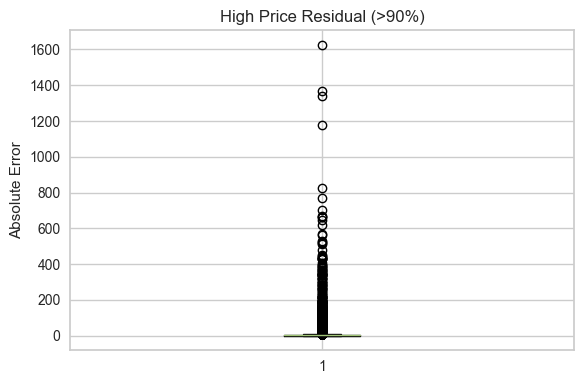

   threshold  count   avg_err  median_err
0       51.0  42944  5.033761    1.596863
📁 JSON saved: ../results\lgbm_20251208_180322_high_price_20251208_180337.json
🖼 PNG saved:  ../images\lgbm_20251208_180322_high_price_20251208_180337.png
   threshold  count   avg_err  median_err
0       51.0  42944  5.033761    1.596863 

➡ STEP2: Sub_cat RMSE ranking
[LightGBM] [Warning] Unknown parameter: gpu


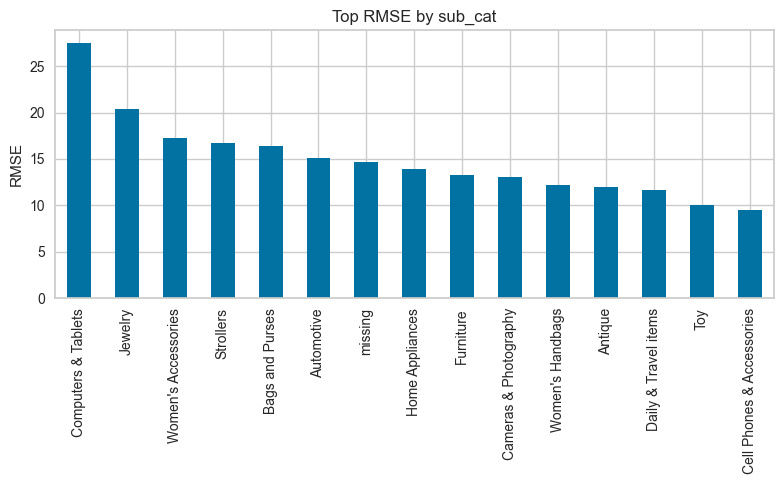

<Figure size 800x550 with 0 Axes>

Computers & Tablets    27.472755
Jewelry                20.373717
Women's Accessories    17.266784
Strollers              16.686960
Bags and Purses        16.434498
                         ...    
Needlecraft             0.126767
Magazines               0.117879
Geekery                 0.096449
Holidays                0.067747
Quilts                  0.029398
Length: 114, dtype: float64
📁 JSON saved: ../results\lgbm_20251208_180322_subcat_rmse_20251208_180356.json
🖼 PNG saved:  ../images\lgbm_20251208_180322_subcat_rmse_20251208_180356.png
Computers & Tablets      27.472755
Jewelry                  20.373717
Women's Accessories      17.266784
Strollers                16.686960
Bags and Purses          16.434498
Automotive               15.133942
missing                  14.649107
Home Appliances          13.933720
Furniture                13.263349
Cameras & Photography    13.056943
dtype: float64 

➡ STEP3: Brand residual + price ratio
[LightGBM] [Warning] Unknown parameter: gpu


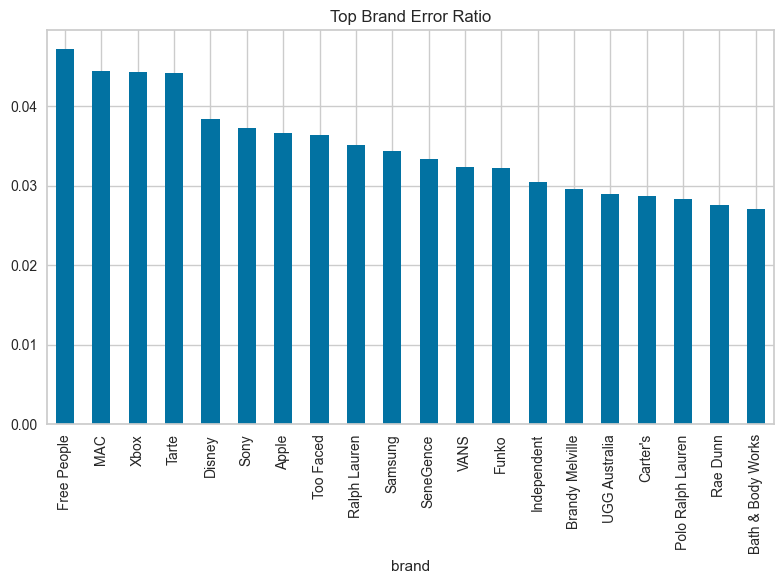

<Figure size 800x550 with 0 Axes>

                       price       err   count  err_ratio
brand                                                    
Free People        37.338249  1.762500    1051   0.047204
MAC                22.298180  0.991571    1593   0.044469
Xbox               30.080315  1.333564    1712   0.044333
Tarte              22.122759  0.977979    1450   0.044207
Disney             17.258808  0.663728    3122   0.038457
Sony               35.454809  1.320929    2412   0.037257
Apple              73.936927  2.711154    5129   0.036668
Too Faced          22.707781  0.826533    1735   0.036399
Ralph Lauren       18.187447  0.638343    1179   0.035098
Samsung            54.791632  1.881719    1219   0.034343
SeneGence          32.842951  1.098687    1213   0.033453
VANS               26.624376  0.860646    1403   0.032326
Funko              29.381668  0.946907    2793   0.032228
Independent        36.602860  1.115163    1818   0.030467
Brandy Melville    18.264448  0.542055    1713   0.029678
UGG Australia 

In [ ]:
results = run_full_error_diagnostic(
    analyzer, models["lightgbm"], prefix="lgbm"  # or voting
)